# 📈 Régression linéaire avec Python

> La régression linéaire est l'algorithme le plus simple en apprentissage automatique, il peut être entraîné de différentes manières. Dans ce cahier, nous allons couvrir les algorithmes linéaires suivants :
> 1. Régression linéaire
> 2. Régresseur de forêt aléatoire (Random Forest Regressor)
---
# 💾 Données

https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8/about_data


# Installation des Librairies

In [1]:
%pip install -q hvplot
%pip install -q matplotlib
%pip install -q seaborn
%pip install -q scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 📤 Import des Libraries

In [2]:
import pandas as pd # Analyse et manipulation de données (utilisation des Pandas DataFrame)
import numpy as np # Fonctions mathématiques
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns # Visualisation de données
import hvplot.pandas # Plots interactifs
import holoviews as hv
hv.extension('bokeh')  # pour format non scientifique
import folium # cartography
import random
import missingno as msno # visualiser les NaN (not a number)
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # pipeline de pré-processing et de modelling
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split # Partitionnage des données

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 💾 Consultation des données

Chargement des données de crimes à Los Angeles entre 2020 et 2024, ainsi que d'un jeu de données externe contenant le revenu moyen par quartier à Los Angeles.

In [3]:
LA_data = pd.read_csv('Crime_Data_from_2020_to_Present_20250424.csv')
Median_income = pd.read_csv('Estimated_income.csv', sep=';')

type(LA_data)
type(Median_income)

pandas.core.frame.DataFrame

Time Conversion

In [4]:
# Conversion de la colonne de date (ex : 'DATE OCC') au bon format
LA_data['DATE OCC'] = pd.to_datetime(LA_data['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p')
# Vérifie le résultat
print(LA_data['DATE OCC'].dtypes)  # ça devrait afficher datetime64[ns]

datetime64[ns]


Extraire heures et minutes de TIME OCC et le combiner avec DATE OCC pour créer une nouvelle colonne.

In [5]:
# 2. S'assurer que TIME OCC est une chaîne de 4 chiffres (ex : 400 → 0400)
LA_data['TIME OCC'] = LA_data['TIME OCC'].astype(str).str.zfill(4)

# 3. Extraire heures et minutes
LA_data['hour'] = LA_data['TIME OCC'].str[:2].astype(int) # "Prends les caractères de l'index 0 jusqu’à l’index 2 (non inclus)"
LA_data['minute'] = LA_data['TIME OCC'].str[2:].astype(int)

# 4. Créer DATE_TIME_OCC en ajoutant l'heure et les minutes à DATE OCC
LA_data['DATE_TIME_OCC'] = LA_data['DATE OCC'] + pd.to_timedelta(LA_data['hour'], unit='h') + pd.to_timedelta(LA_data['minute'], unit='m')

# 5. Vérification
print(LA_data[['DATE OCC', 'TIME OCC', 'DATE_TIME_OCC']].head())

    DATE OCC TIME OCC       DATE_TIME_OCC
0 2020-03-01     2130 2020-03-01 21:30:00
1 2020-02-08     1800 2020-02-08 18:00:00
2 2020-11-04     1700 2020-11-04 17:00:00
3 2020-03-10     2037 2020-03-10 20:37:00
4 2020-09-09     0630 2020-09-09 06:30:00


Ne gardons que 2024 pour le moment

In [6]:
LA_data_2024 = LA_data[LA_data['DATE OCC'].dt.year == 2024]
# test date 2024
print(LA_data_2024['DATE OCC'].min())

2024-01-01 00:00:00


Afficher les 5 premières lignes du jeu de données sur le revenu moyen par quartier.

In [7]:
Median_income.head()

,AREA,Estimated_income
0,77th Street,54781
1,Central,60473
2,Devonshire,70000
3,Foothill,70000
4,Harbor,72066


Affiche les 5 premières lignes du jeu de données sur les crimes à Los Angeles

In [8]:
LA_data_2024.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,hour,minute,DATE_TIME_OCC
877329,242108414,04/25/2024 12:00:00 AM,2024-04-25,1600,21,Topanga,2146,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,998.0,NaN,NaN,21400 SHERMAN WY,NaN,34.2010,-118.5977,16,0,2024-04-25 16:00:00
877330,240604934,01/21/2024 12:00:00 AM,2024-01-21,1510,6,Hollywood,668,2,624,BATTERY - SIMPLE ASSAULT,...,NaN,NaN,NaN,1300 N WESTERN AV,NaN,34.0944,-118.3125,15,10,2024-01-21 15:10:00
877331,241110315,08/29/2024 12:00:00 AM,2024-08-28,1500,11,Northeast,1123,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,NaN,NaN,NaN,3600 BRUNSWICK AV,NaN,34.1187,-118.2604,15,0,2024-08-28 15:00:00
877332,242107187,03/22/2024 12:00:00 AM,2024-03-22,1815,21,Topanga,2145,2,624,BATTERY - SIMPLE ASSAULT,...,NaN,NaN,NaN,22000 GILMORE ST,NaN,34.1876,-118.6070,18,15,2024-03-22 18:15:00
877333,241010884,09/06/2024 12:00:00 AM,2024-09-05,1800,10,West Valley,1027,1,330,BURGLARY FROM VEHICLE,...,NaN,NaN,NaN,6800 LOUISE AV,NaN,34.1939,-118.5098,18,0,2024-09-05 18:00:00


Fusion des deux datasets par le nom du quartier

In [9]:
# Fusion des deux datasets par le nom du quartier
LA_data_2024 = LA_data_2024.merge(Median_income, left_on='AREA NAME', right_on='AREA', how='left')


Affiche le head des données fusionnées

In [10]:
# Affiche le head des données fusionnées
LA_data_2024.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA_x,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Crm Cd 4,LOCATION,Cross Street,LAT,LON,hour,minute,DATE_TIME_OCC,AREA_y,Estimated_income
0,242108414,04/25/2024 12:00:00 AM,2024-04-25,1600,21,Topanga,2146,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,NaN,21400 SHERMAN WY,NaN,34.2010,-118.5977,16,0,2024-04-25 16:00:00,Topanga,120000
1,240604934,01/21/2024 12:00:00 AM,2024-01-21,1510,6,Hollywood,668,2,624,BATTERY - SIMPLE ASSAULT,...,NaN,1300 N WESTERN AV,NaN,34.0944,-118.3125,15,10,2024-01-21 15:10:00,Hollywood,59393
2,241110315,08/29/2024 12:00:00 AM,2024-08-28,1500,11,Northeast,1123,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,NaN,3600 BRUNSWICK AV,NaN,34.1187,-118.2604,15,0,2024-08-28 15:00:00,Northeast,89168
3,242107187,03/22/2024 12:00:00 AM,2024-03-22,1815,21,Topanga,2145,2,624,BATTERY - SIMPLE ASSAULT,...,NaN,22000 GILMORE ST,NaN,34.1876,-118.6070,18,15,2024-03-22 18:15:00,Topanga,120000
4,241010884,09/06/2024 12:00:00 AM,2024-09-05,1800,10,West Valley,1027,1,330,BURGLARY FROM VEHICLE,...,NaN,6800 LOUISE AV,NaN,34.1939,-118.5098,18,0,2024-09-05 18:00:00,West Valley,85000


Voici les différents quartiers de Los Angeles présents dans le dataset. Il y en a 21.

In [11]:
# Attributs uniques de la colonne AREA NAME
print(sorted(LA_data_2024['AREA NAME'].unique()))


['77th Street', 'Central', 'Devonshire', 'Foothill', 'Harbor', 'Hollenbeck', 'Hollywood', 'Mission', 'N Hollywood', 'Newton', 'Northeast', 'Olympic', 'Pacific', 'Rampart', 'Southeast', 'Southwest', 'Topanga', 'Van Nuys', 'West LA', 'West Valley', 'Wilshire']


In [12]:
# Comptage du nombre de lignes
LA_data_2024.count()

DR_NO               127572
Date Rptd           127572
DATE OCC            127572
TIME OCC            127572
AREA_x              127572
AREA NAME           127572
Rpt Dist No         127572
Part 1-2            127572
Crm Cd              127572
Crm Cd Desc         127572
Mocodes              97575
Vict Age            127572
Vict Sex             98370
Vict Descent         98366
Premis Cd           127566
Premis Desc         127517
Weapon Used Cd       23785
Weapon Desc          23785
Status              127571
Status Desc         127572
Crm Cd 1            127572
Crm Cd 2              5065
Crm Cd 3               139
Crm Cd 4                 2
LOCATION            127572
Cross Street         15739
LAT                 127572
LON                 127572
hour                127572
minute              127572
DATE_TIME_OCC       127572
AREA_y              127572
Estimated_income    127572
dtype: int64

#### drop
Je supprime les colonnes suivantes car elles ne sont pas pertinentes pour notre analyse.
- "DR_NO" : numéro du district
- "Date Rptd" : date du rapport
- "DATE OCC" : date du crime - redondant avec la colonne créée au format temps
- "TIME OCC" : heure du crime - redondant avec la colonne créée au format temps
- "AREA" : code de la zone 
- "Rpt Dist No" : zones contenues dans les quartiers
- "Part 1-2" : catégorie de crime, crimes de type 2 sont plus graves
- "Premis Desc" : structure, véhicule, ou emplacement où le crime a été commis
- "Weapon Used Cd": code pour l'arme utilisée
- "Status" : code pour statut du crime (AA = Adult arrested, IC = Invest cont, ...)
- "Status Desc" : description du statut du crime Adult arrested, Invest cont, ...
- "Crm Cd 2" : autres crimes commis moins important que le crime le plus grave. Je ne garde que le Crm Cd 1
- "Crm Cd 3" : idem
- "Crm Cd 4" : idem
- "LOCATION" : adresse du crime arrondie au 100ème bloc le plus proche (pour anonymité)
- "Cross Street" : une autre adresse arrondie
- "hour" : heure - redondant avec la colonne créée au format temps
- "minute" : minute - redondant avec la colonne créée au format temps
- "count_x" : résidus de la fusion de données
- "count_y" : résidus de la fusion de données



In [13]:
colonnes_a_supprimer = [
    "DR_NO", "Date Rptd", "DATE OCC", "TIME OCC", "Rpt Dist No",
    "Premis Desc", "Weapon Used Cd", "Status", "Status Desc",
    "Crm Cd 2", "Crm Cd 3", "Crm Cd 4", "LOCATION", "Cross Street", "hour",
    "minute"
]

LA_data_2024 = LA_data_2024.drop(columns=colonnes_a_supprimer)


In [14]:
LA_data_2024.head()

,AREA_x,AREA NAME,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Weapon Desc,Crm Cd 1,LAT,LON,DATE_TIME_OCC,AREA_y,Estimated_income
0,21,Topanga,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1606 0344 1402 0302 1822 1227 1420,0,M,W,101.0,HAND GUN,420.0,34.2010,-118.5977,2024-04-25 16:00:00,Topanga,120000
1,6,Hollywood,2,624,BATTERY - SIMPLE ASSAULT,1822 0400 0416,22,F,B,517.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",624.0,34.0944,-118.3125,2024-01-21 15:10:00,Hollywood,59393
2,11,Northeast,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),NaN,0,NaN,NaN,101.0,NaN,420.0,34.1187,-118.2604,2024-08-28 15:00:00,Northeast,89168
3,21,Topanga,2,624,BATTERY - SIMPLE ASSAULT,0448 2021 0361 0603,58,M,O,102.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",624.0,34.1876,-118.6070,2024-03-22 18:15:00,Topanga,120000
4,10,West Valley,1,330,BURGLARY FROM VEHICLE,1300 1822 0344,49,M,W,707.0,NaN,330.0,34.1939,-118.5098,2024-09-05 18:00:00,West Valley,85000


**Instruction:** Calculer les statistiques suivantes pour chaque colonne:
- moyenne, écart type
- valeur minimale, maximale
- quartiles

In [15]:
# Code ici
LA_data_2024.describe()

,AREA_x,Part 1-2,Crm Cd,Vict Age,Premis Cd,Crm Cd 1,LAT,LON,DATE_TIME_OCC,Estimated_income
count,127572.000000,127572.000000,127572.000000,127572.000000,127566.000000,127572.000000,127572.000000,127572.000000,127572,127572.000000
mean,10.571983,1.312075,496.632247,23.472008,296.405155,496.520396,34.076695,-118.357466,2024-05-22 07:40:35.689492992,69521.025915
min,1.000000,1.000000,110.000000,0.000000,101.000000,110.000000,33.705900,-118.667600,2024-01-01 00:01:00,50806.000000
25%,5.000000,1.000000,341.000000,0.000000,101.000000,341.000000,34.020900,-118.433400,2024-02-23 00:38:45,56001.000000
50%,11.000000,1.000000,442.000000,24.000000,145.000000,442.000000,34.059900,-118.330100,2024-04-26 22:00:00,60473.000000
75%,16.000000,2.000000,624.000000,39.000000,501.000000,624.000000,34.168600,-118.274900,2024-08-17 19:10:00,72066.000000
max,21.000000,2.000000,956.000000,99.000000,975.000000,956.000000,34.329700,-118.156000,2024-12-30 23:00:00,120000.000000
std,6.187865,0.463342,188.436858,22.440919,233.637041,188.318652,0.111906,0.104795,NaN,17465.018318


# Analyse exploratoire des données (AED)


## Cartographie des crimes commis en 2024

In [16]:
# Supprimer les valeurs manquantes
df = LA_data_2024.dropna(subset=['LAT', 'LON'])

In [17]:
# Nettoyer les données : enlever les lignes sans coordonnées ou sans quartier
df = LA_data_2024.dropna(subset=['LAT', 'LON', 'AREA NAME'])

# Créer une carte centrée sur Los Angeles
m = folium.Map(location=[34.05, -118.25], zoom_start=10)

# Générer une couleur unique pour chaque quartier (AREA NAME)
areas = df['AREA NAME'].unique()
colors = {area: f"#{random.randint(0, 0xFFFFFF):06x}" for area in areas}

# Ajouter les points
for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=2,
        color=colors[row['AREA NAME']],
        fill=True,
        fill_color=colors[row['AREA NAME']],
        fill_opacity=0.7,
        popup=folium.Popup(f"Quartier : {row['AREA NAME']}", parse_html=True)
    ).add_to(m)

# Sauvegarder la carte
m.save('carte_crimes_LA_coloree.html')

La carte des crimes est disponible sous le nom de carte_crimes_LA_coloree.

In [18]:
# Carte clusterisée
# Créer une carte centrée sur LA
m = folium.Map(location=[34.05, -118.25], zoom_start=10)

# Ajouter des points
for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=2,
        color='red',
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

# Sauver la carte
m.save('carte_crimes_LA.html')

Une carte clusterisée des crimes est disponible sous le nom de carte_crimes_LA.

## Exploration des données

### Relation à l'age des victimes

Suppression des lignes où l'age de la victime est 0 car ces données ne sont pas exploitables dans nos modèles.

In [19]:
# Suppression des lignes où l'âge est égal à 0
LA_data_2024 = LA_data_2024[LA_data_2024['Vict Age'] != 0]


In [20]:
LA_data_2024.hvplot.hist("Vict Age")

:Histogram   [Vict Age]   (Vict Age_count)

L'âge moyen est situé aux alentours de 34 ans. 

### Relation au revenu moyen estimé par foyer par quartier

In [21]:
LA_data_2024.hvplot.hist("Estimated_income")

:Histogram   [Estimated_income]   (Estimated_income_count)

#### Relation entre age des victimes et revenu moyen estimé dans le quartier

In [22]:
# Calculer la fréquence des paires (Vict Age, Estimated_income)
frequency = LA_data_2024.groupby(['Vict Age', 'Estimated_income']).size().reset_index(name='count')

# Fusionner ces informations avec les données originales
LA_data_2024 = LA_data_2024.merge(frequency, on=['Vict Age', 'Estimated_income'], how='left')

LA_data_2024.hvplot.scatter(
    x='Vict Age',
    y='Estimated_income',
    size='count',  # Utiliser 'count' pour la taille des points
    width=800,
    height=500
).opts(
    title='Relation entre l\'Âge des Victimes et les Revenus Estimés',
    xlabel='Âge des Victimes',
    ylabel='Revenu Estimé ($)',
    color='blue',  # Couleur des points
    tools=['hover'],  # Affichage des valeurs lors du survol
    show_grid=True,  # Affichage de la grille
    legend_position='top_left'  # Position de la légende
)


:Scatter   [Vict Age]   (Estimated_income,count)

In [23]:
# Calcul des statistiques descriptives entre l'age et le revenu moyen estimé par foyer
stats_by_area = LA_data_2024.groupby('Estimated_income').agg(
    count=('Estimated_income', 'size'),
    mean_age=('Vict Age', 'mean'),
    std_age=('Vict Age', 'std'),
    min_age=('Vict Age', 'min'),
    max_age=('Vict Age', 'max'),
    median_age=('Vict Age', 'median')
).reset_index()

# Afficher les premières lignes du tableau
print(stats_by_area)


    Estimated_income  count   mean_age    std_age  min_age  max_age  \
0              50806   3168  37.929924  15.436093        2       99   
1              54781   4344  39.007827  15.399939        2       99   
2              55000  11938  34.947562  14.593246        2       99   
3              56001   1989  39.884867  14.878222        4       99   
4              58000   7497  38.031746  14.570672        2       99   
5              59393   4157  37.783498  13.793674        2       99   
6              60473   5463  36.350540  12.715947        2       99   
7              68000   3661  40.372030  15.586681        3       99   
8              70000  13325  40.617036  15.756379        2       99   
9              72066   2833  40.842570  16.282072        2       99   
10             85000   3377  42.714540  16.390351        2       99   
11             89168   2884  39.519764  14.261128        4       99   
12             90000   5254  40.444043  14.909659        2       99   
13    

Nous constatons que l'age moyen des victimes se situe entre 37 et 40 ans avec un écart-type de 15 ans. Il n'y a pas de différence notoire dans l'âge moyen des victimes selon le quartier où elles se trouvent.

### Nombre de crimes en fonction du revenu moyen par quartier

In [24]:
# Compter le nombre de crimes par 'Estimated_income'
crimes_by_income = LA_data_2024.groupby('Estimated_income').size().reset_index(name='crime_count')

# Afficher les premières lignes du tableau
print(crimes_by_income)


    Estimated_income  crime_count
0              50806         3168
1              54781         4344
2              55000        11938
3              56001         1989
4              58000         7497
5              59393         4157
6              60473         5463
7              68000         3661
8              70000        13325
9              72066         2833
10             85000         3377
11             89168         2884
12             90000         5254
13            104627         3111
14            120000         3841


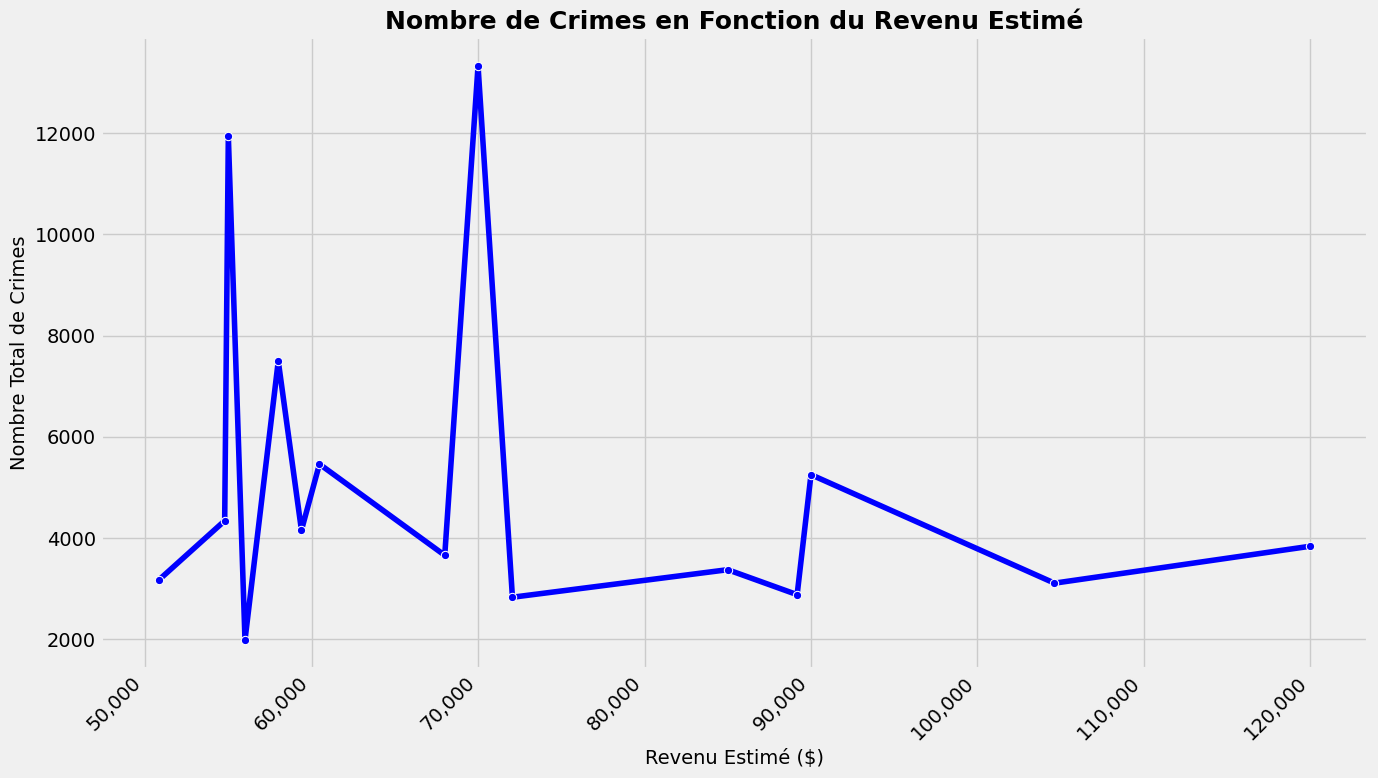

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# On suppose que votre DataFrame LA_data_2024 est déjà chargé
# Votre code pour préparer les données
crimes_by_income = LA_data_2024.groupby('Estimated_income').size().reset_index(name='crime_count')

# --- Création du graphique ---

# 1. Définir un style esthétique pour le graphique
plt.style.use('fivethirtyeight')

# 2. Créer la figure et les axes avec une taille adaptée
plt.figure(figsize=(14, 8))

# 3. Créer le graphique en ligne avec Seaborn
# On ajoute des marqueurs ('o') pour bien voir chaque point de donnée
sns.lineplot(
    data=crimes_by_income,
    x='Estimated_income',
    y='crime_count',
    marker='o',
    linestyle='-',
    color='b' # 'b' pour bleu
)

# 4. Ajouter des titres et des étiquettes claires
plt.title("Nombre de Crimes en Fonction du Revenu Estimé", fontsize=18, fontweight='bold')
plt.xlabel("Revenu Estimé ($)", fontsize=14)
plt.ylabel("Nombre Total de Crimes", fontsize=14)

# 5. Améliorer la lisibilité des axes
plt.xticks(rotation=45, ha='right') # pivote les étiquettes pour éviter les superpositions
plt.gca().get_xaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ',')) # Met un séparateur de milliers
)

# 6. Assurer un affichage propre et afficher le graphique
plt.tight_layout()
plt.show()

Nous constatons qu'il y a plus de crimes qui sont commis dans des quartiers où le revenu moyen par foyer est plus bas. En effet la majeur partie des crimes sont commis dans les quartiers où le revenu moyen par foyer se situe entre 50'000 et 74'000 $.

## Etude de l'activité criminelle au travers du temps
Prenons le temps d'analyser la période où les crimes sont commis durant l'année, par quartier, mais également dans la journée.
### Analyse sur l'année
#### Préparation des données
Transformation des données au format datetime.


In [26]:
# On suppose que votre DataFrame LA_data_2024 est déjà chargé
df = LA_data_2024

# ÉTAPE CRUCIALE : S'assurer que la colonne est au bon format date/heure
# Cette ligne convertit la colonne si elle est sous forme de texte.
# Si elle est déjà au bon format, cette opération est sans danger.
df['DATE_TIME_OCC'] = pd.to_datetime(df['DATE_TIME_OCC'])

# On compte le nombre de crimes pour chaque jour
# .dt.floor('D') arrondit la date au jour le plus proche (enlève les heures/minutes)
crimes_per_day = df.groupby(df['DATE_TIME_OCC'].dt.floor('D')).size()

# On renomme la série pour plus de clarté
crimes_per_day.name = 'crime_count'

# On réinitialise l'index pour avoir une colonne 'DATE_TIME_OCC' et une colonne 'crime_count'
crimes_per_day = crimes_per_day.reset_index()

#### Création du graphique à courbe - nombre de crimes à l'année

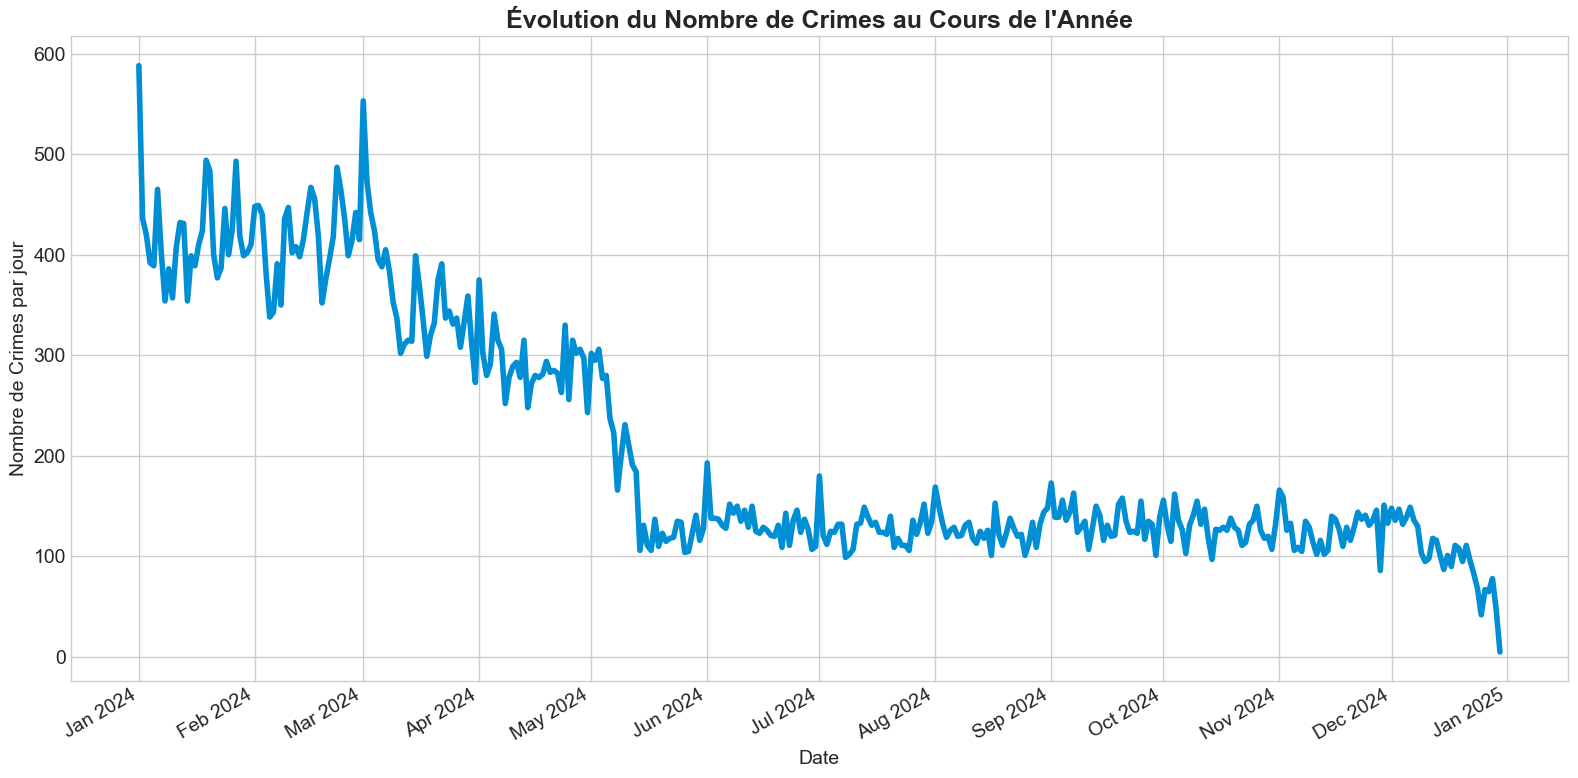

In [27]:
# Définir un style esthétique
plt.style.use('seaborn-v0_8-whitegrid')

# Créer la figure avec une taille adaptée pour une série temporelle
plt.figure(figsize=(16, 8))

# Créer le graphique à courbe
sns.lineplot(
    data=crimes_per_day,
    x='DATE_TIME_OCC',
    y='crime_count'
)

# Améliorer les titres et les étiquettes
plt.title("Évolution du Nombre de Crimes au Cours de l'Année", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Nombre de Crimes par jour", fontsize=14)

# Améliorer le format de l'axe des dates pour une meilleure lisibilité
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator()) # Une marque par mois
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Affiche "Jan 2024", "Fév 2024", etc.
plt.gcf().autofmt_xdate() # Pivote les dates pour éviter les superpositions

# Afficher le graphique
plt.tight_layout()
plt.show()

Nous pouvons constater que les crimes ont tendance à baisser tout au long de l'année. Ils sont plus fréquent de janvier avec à mai avec en moyenne 500 crimes par jour, puis il y a une baisse du nombre de crimes par jour qui passe de 400 à 250 au mois de juin.La moyenne de 250 reste constante pour le restant de l'année avant de chuter drastiquement entre décembre et janvier.
La raison pour la quelle il y a une aussi grande différence entre janvier 2024 et janvier 2025 n'est pas disponible mais je suppose que cela peut s'expliquer par les vacances de fin d'année où il y aurait moins d'officiers disponibles, ou moins d'officiers souhaitant rédiger des rapports de police.
Autre hypothèse, une partie des données n'a pas été encore numérisée ou bien les données ont été perdues dans le processus de mise en ligne, car je ne suis pas certain que ces chiffres soient corrects.

### Analyse de la criminalité dans une journée

#### Préparation des données
Extraction de l'heure des crimes

In [28]:
df = LA_data_2024

# S'assurer que la colonne est au bon format date/heure
df['DATE_TIME_OCC'] = pd.to_datetime(df['DATE_TIME_OCC'])

# Extraire l'heure de chaque crime (valeur de 0 à 23)
df['hour'] = df['DATE_TIME_OCC'].dt.hour

# --- Préparation pour le Donut Chart : Définir les tranches horaires ---
# On définit les bornes et les noms de nos tranches
bins = [-1, 5, 11, 17, 23] # Les heures de coupure : 0-5, 6-11, 12-17, 18-23
labels = ['Nuit (0h-6h)', 'Matin (6h-12h)', 'Après-midi (12h-18h)', 'Soirée (18h-0h)']

# On crée une nouvelle colonne avec la tranche horaire correspondante
df['time_slot'] = pd.cut(df['hour'], bins=bins, labels=labels, right=False)

# On compte le nombre de crimes par tranche horaire
crimes_by_slot = df['time_slot'].value_counts()

### Graphique 1 : La Répartition par Tranche Horaire (Donut Chart)

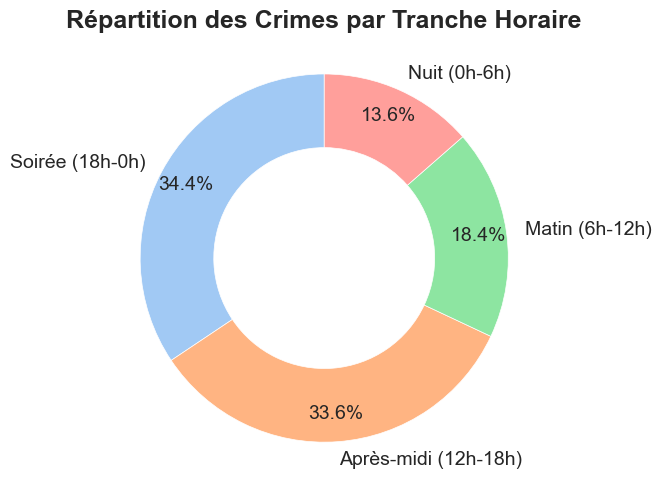

In [29]:
# Définir une palette de couleurs
colors = sns.color_palette('pastel')[0:4]

# Créer la figure
plt.figure(figsize=(5, 5))

# Créer le graphique en Donut
plt.pie(
    crimes_by_slot,
    labels=crimes_by_slot.index,
    colors=colors,
    autopct='%.1f%%', # Affiche les pourcentages avec une décimale
    startangle=90,
    pctdistance=0.85, # Distance du texte de pourcentage par rapport au centre
    wedgeprops=dict(width=0.4, edgecolor='w') # Crée le "trou" au milieu
)

# Assurer que le cercle est bien un cercle
plt.axis('equal') 
plt.title("Répartition des Crimes par Tranche Horaire", fontsize=18, fontweight='bold', pad=20)

plt.show()

Les crimes sont majoritairement commins dans l'après-midi (32.4%) et la soirée (35.7%).

### Graphique 2 : L'Horloge du Crime (Graphique Polaire)
Distribution heure par heure des crimes commis.

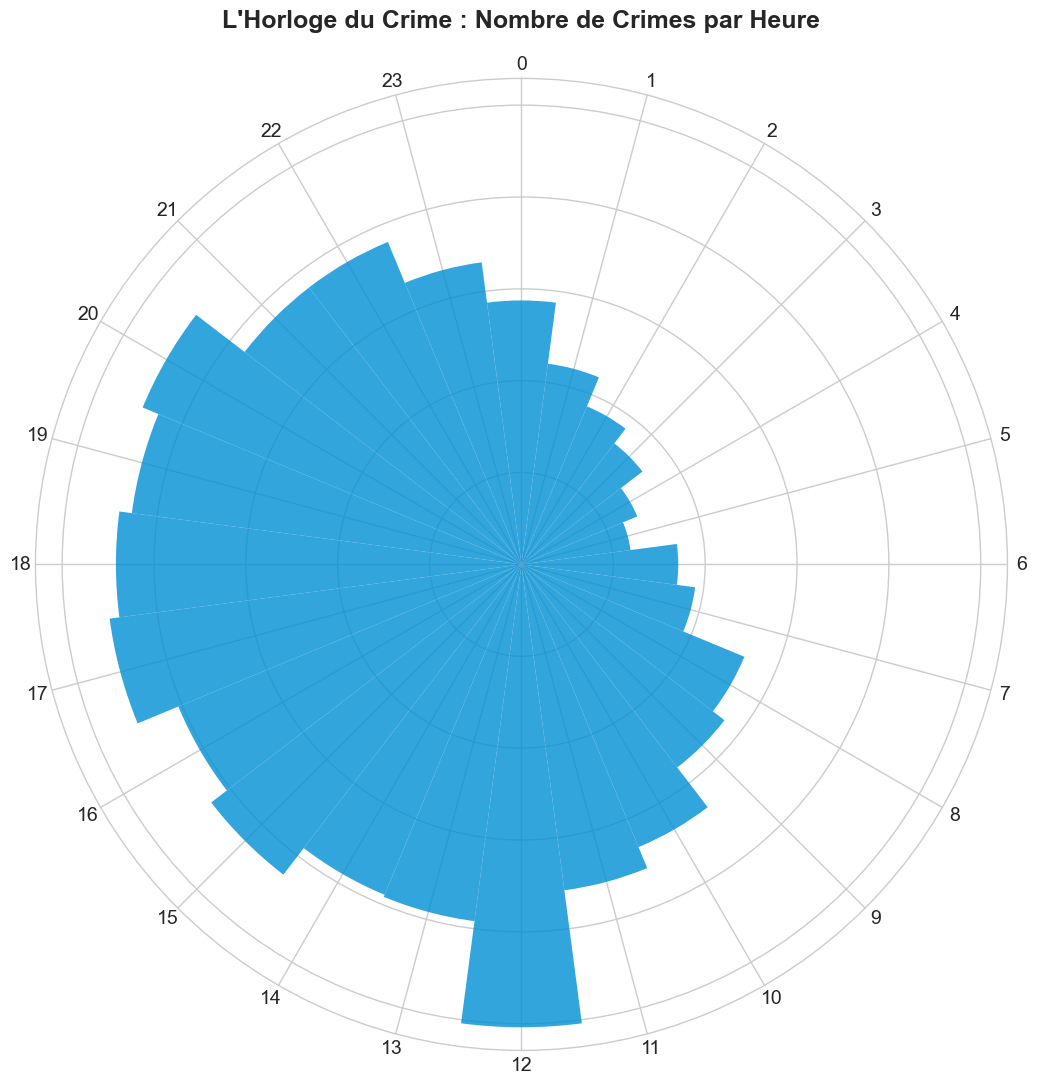

In [30]:
# Préparation des données pour ce graphique : compter les crimes par heure
crimes_by_hour = df.groupby('hour').size()

# Créer la figure et l'axe polaire
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': 'polar'})

# Angle de chaque barre (24 heures = 2*pi radians)
theta = np.linspace(0.0, 2 * np.pi, 24, endpoint=False)

# Créer les barres
bars = ax.bar(theta, crimes_by_hour, width=(2 * np.pi / 24), alpha=0.8)

# Personnalisation pour ressembler à une horloge
ax.set_theta_direction(-1) # Met les heures dans le sens des aiguilles d'une montre
ax.set_theta_offset(np.pi / 2.0) # Met le 0 en haut
ax.set_xticks(theta) # Positionne les étiquettes des heures
ax.set_xticklabels(range(24)) # Affiche les heures 0-23
ax.set_yticklabels([]) # Cache les étiquettes radiales (le nombre de crimes)

# Ajouter un titre
ax.set_title("L'Horloge du Crime : Nombre de Crimes par Heure", fontsize=18, fontweight='bold', pad=20)

plt.show()

Le cadran de 24h heures montre que la majorité des crimes sont commis l'après-midi avec une pointe à midi suivi d'une seconde pointe à 18h. 19h et 20h sont des heures où les crimes sont très souvent commis.

## Analyse socio-temporelle
Analyse de l'impact du revenu moyen par foyer sur la temporalité des crimes commis à l'année et à la journée.
J'ai décidé de classer les revenus moyen par quartiles.
- Q1 : les 25% de revenus les plus faibles
- Q2 : de 25% à 50%
- Q3 : de 50% à 75%
- Q4 : les 25% de revenus les plus élevés

#### Préparation des Données (Création des Quartiles)

In [31]:
df = LA_data_2024

# ÉTAPE CRUCIALE : Créer les 4 quartiles de revenus
# pd.qcut segmente les données en quantiles de taille égale.
quartile_labels = ['Q1 (Faible)', 'Q2 (Moyen-Faible)', 'Q3 (Moyen-Élevé)', 'Q4 (Élevé)']
df['income_quartile'] = pd.qcut(
    df['Estimated_income'],
    q=4,
    labels=quartile_labels
)

# S'assurer que la colonne de date est au bon format
df['DATE_TIME_OCC'] = pd.to_datetime(df['DATE_TIME_OCC'])

# Extraire l'année et le nom du jour de la semaine
df['year'] = df['DATE_TIME_OCC'].dt.year
df['day_of_week'] = df['DATE_TIME_OCC'].dt.day_name()

#### Graphique 1 : Analyse mensuelle par quartile de Revenu moyen par foyer

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# On suppose que votre DataFrame LA_data_2024 est déjà chargé
df = LA_data_2024

# Créer les 4 quartiles de revenus (comme précédemment)
quartile_labels = ['Q1 (Faible)', 'Q2 (Moyen-Faible)', 'Q3 (Moyen-Élevé)', 'Q4 (Élevé)']
df['income_quartile'] = pd.qcut(
    df['Estimated_income'],
    q=4,
    labels=quartile_labels
)

# S'assurer que la colonne de date est au bon format
df['DATE_TIME_OCC'] = pd.to_datetime(df['DATE_TIME_OCC'])

# --- NOUVELLE ÉTAPE ---
# Créer une colonne représentant le mois de l'année (ex: '2024-01')
# .dt.to_period('M') est parfait pour cela, il conserve l'ordre chronologique
df['year_month'] = df['DATE_TIME_OCC'].dt.to_period('M')

# Préparer les données : grouper par mois/année et par quartile de revenu
crimes_by_month_income = df.groupby(['year_month', 'income_quartile']).size().reset_index(name='crime_count')

# On convertit la colonne 'year_month' en timestamp pour un meilleur affichage
# C'est une astuce pour que seaborn gère mieux l'axe des dates
crimes_by_month_income['year_month'] = crimes_by_month_income['year_month'].dt.to_timestamp()

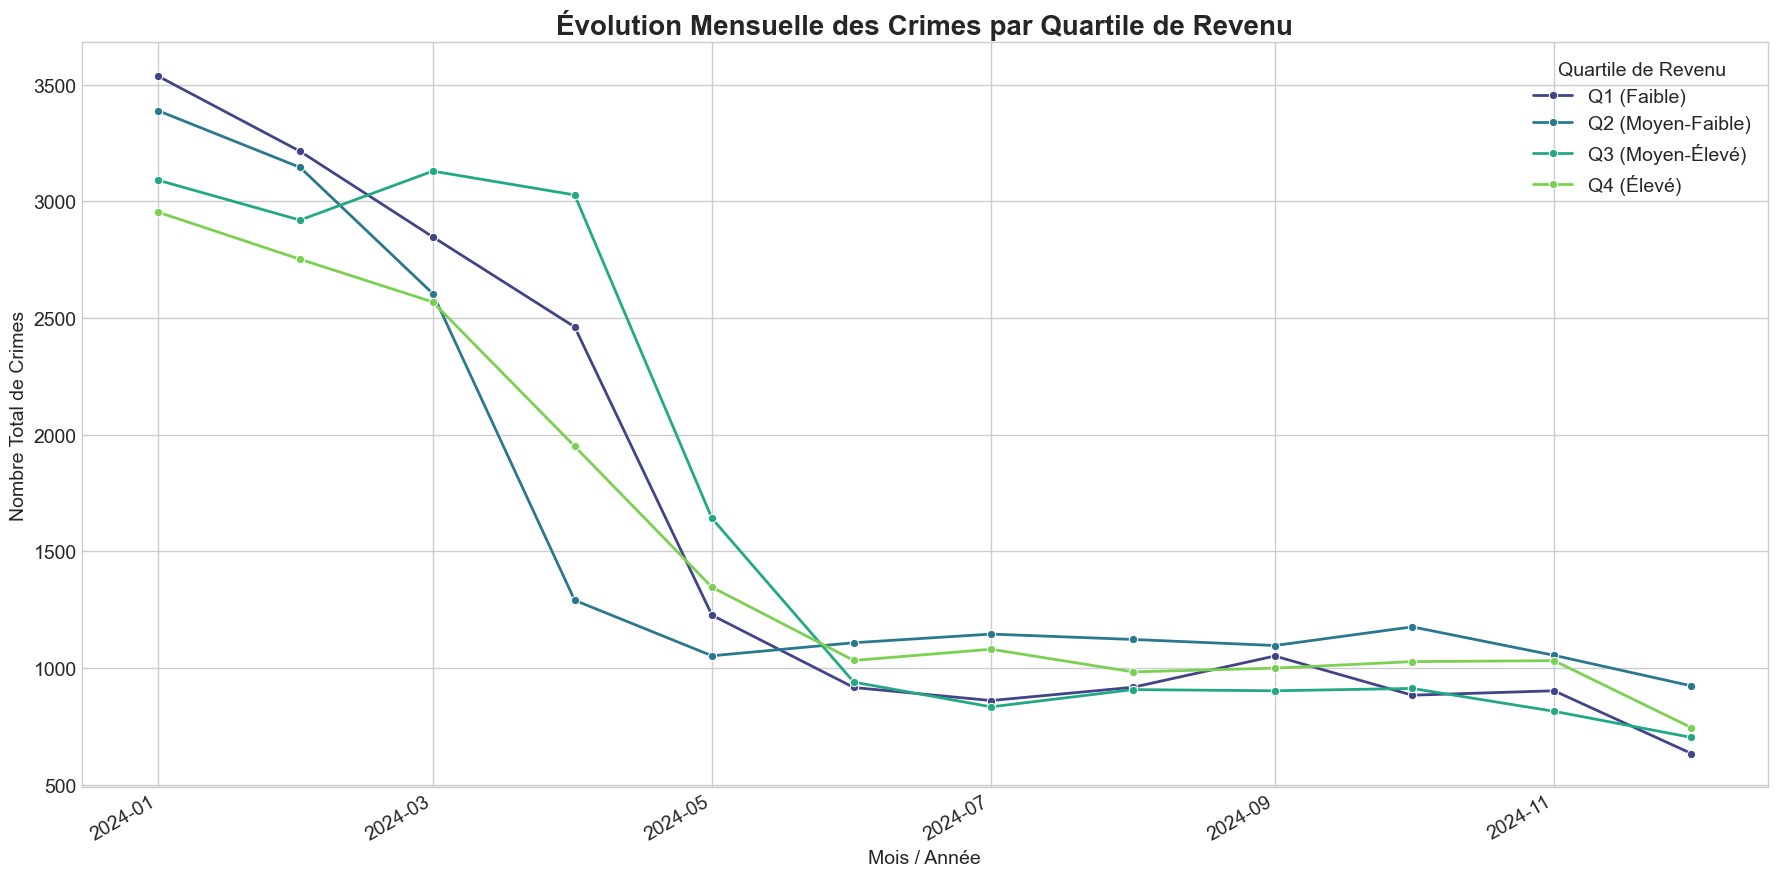

In [33]:
# Définir un style esthétique
plt.style.use('seaborn-v0_8-whitegrid')

# Créer la figure et les axes
plt.figure(figsize=(18, 9))

# Créer le graphique en ligne
sns.lineplot(
    data=crimes_by_month_income,
    x='year_month',
    y='crime_count',
    hue='income_quartile',
    palette='viridis',
    marker='o',
    linewidth=2
)

# Améliorer les titres, étiquettes et légendes
plt.title("Évolution Mensuelle des Crimes par Quartile de Revenu", fontsize=20, fontweight='bold')
plt.xlabel("Mois / Année", fontsize=14)
plt.ylabel("Nombre Total de Crimes", fontsize=14)
plt.legend(title='Quartile de Revenu')

# Améliorer la lisibilité de l'axe des dates
# Cette ligne pivote les dates si elles se superposent
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

Les courbes se suivent au cours de l'année et le revenu moyen par foyer n'a pas l'air d'être impactant sur la quantité de crimes au travers des mois.

#### Graphique 2 : Analyse par jour en fonction du revenu moyen par foyer

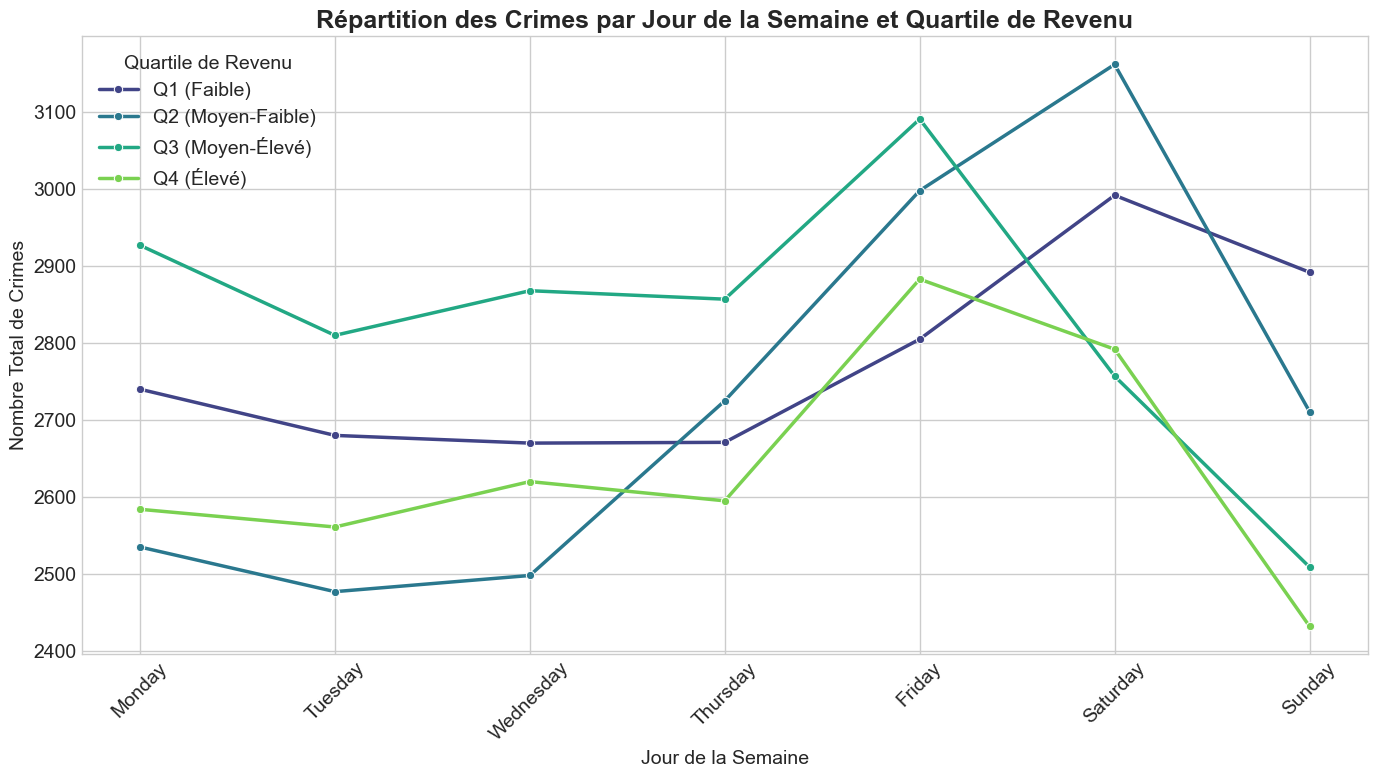

In [34]:
# 1. Préparer les données : grouper par jour de la semaine et par quartile
crimes_by_day_income = df.groupby(['day_of_week', 'income_quartile']).size().reset_index(name='crime_count')

# 2. Ordonner les jours de la semaine correctement
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
crimes_by_day_income['day_of_week'] = pd.Categorical(
    crimes_by_day_income['day_of_week'],
    categories=days_order,
    ordered=True
)
crimes_by_day_income = crimes_by_day_income.sort_values('day_of_week')


# 3. Créer le graphique
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=crimes_by_day_income,
    x='day_of_week',
    y='crime_count',
    hue='income_quartile',
    palette='viridis',
    marker='o',
    linewidth=2.5
)

# 4. Améliorer les titres et légendes
plt.title("Répartition des Crimes par Jour de la Semaine et Quartile de Revenu", fontsize=18, fontweight='bold')
plt.xlabel("Jour de la Semaine", fontsize=14)
plt.ylabel("Nombre Total de Crimes", fontsize=14)
plt.legend(title='Quartile de Revenu')
plt.xticks(rotation=45) # Pivote les noms des jours pour une meilleure lisibilité

plt.tight_layout()
plt.show()

Les courbes de fréquence des crimes par jour sont relativement similaires, seulement avec une proportion de crimes plus élevés pour les zones avec des revenus moyen par foyer plus faible. Toutefois, nous pouvons noter que pour le quartile 2 (25% - 50%), revenu moyen- faible, il y a proportionnellement moins de crimes commis en début de semaine comparé aux autres quartiles. De plus ce quartile contient proportionnellement le plus de crime commis en fin de semaine. Cette tendance est moins prononcée pour les autres quartiles. 

## Etude de la corrélation des variables

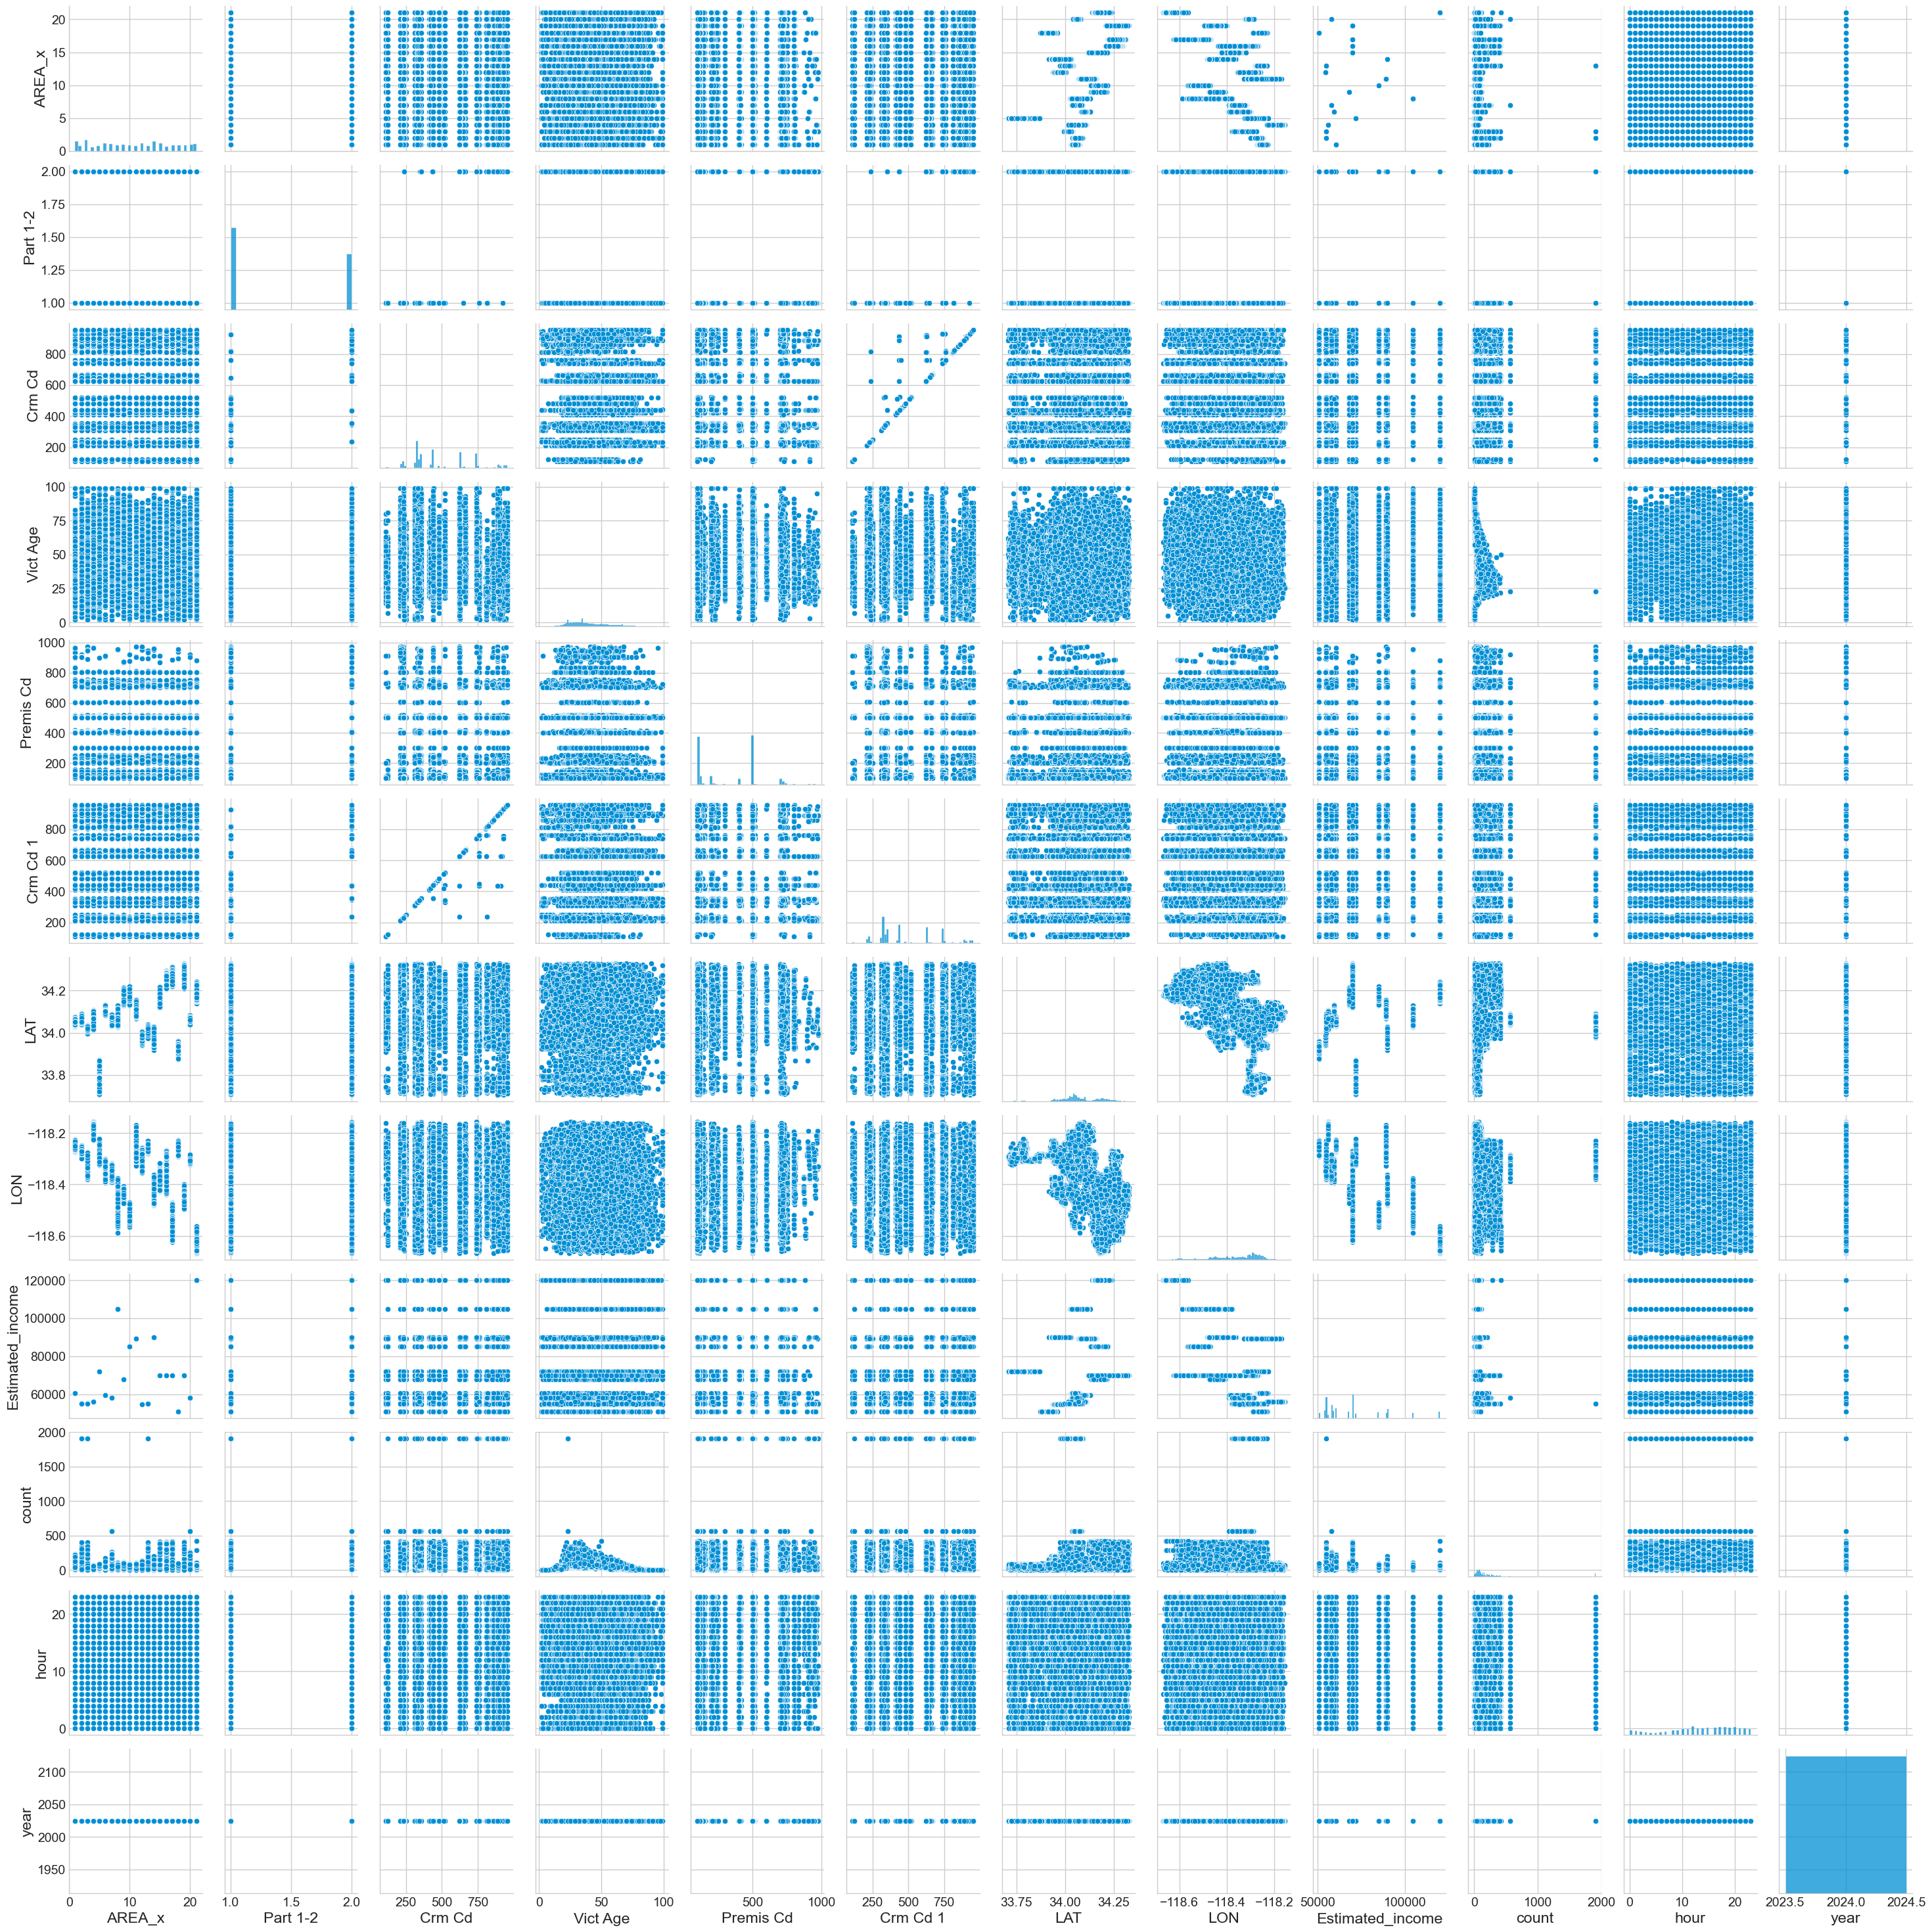

In [35]:
sns.pairplot(LA_data_2024)

Le graphique de corrélation entre les variables n'est pas parlant car nous pouvons voir que la majorité des variables sont des codes et la répartition par classe (codes) est uniforme. En somme, ce graphique de corrélation ne nous apprend rien. Il faut décortiquer les variables.

### Matrice de corrélation
La matrice de corrélation montre que les variables sont extrêmement peu corrélés, hormis pour la corrélation entre revenu moyen par foyer la longitude. Mais est-ce bien correct ? Nous verrons ceci plus tard.

In [36]:
correlation_matrix = LA_data_2024.corr(numeric_only=True)

<Axes: >

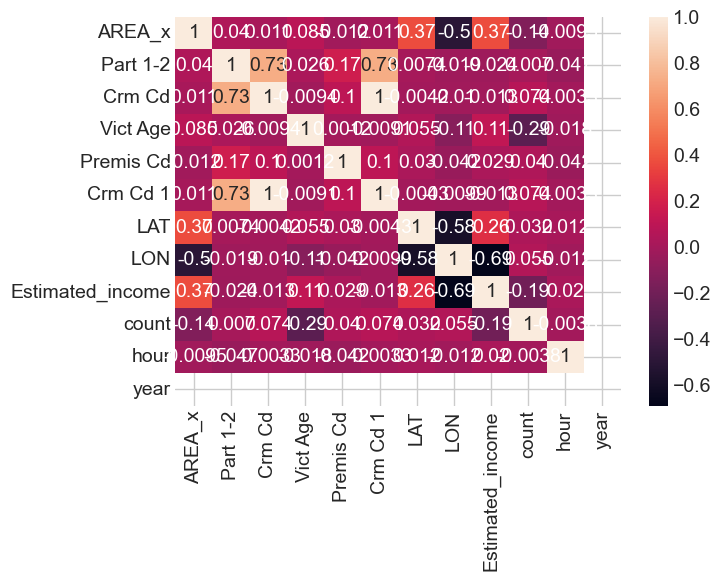

In [37]:
sns.heatmap(correlation_matrix, annot=True)

# Transformation des variables
## Sommaire des données 
J'imprine les données pour y voir plus clair et pour savoir quelles variables transformer.
Nous avons beaucoup de variables codées ainsi que des variables au format texte. Il faut mapper (assigner des classes numériques) aux variables codées et ne garder que des variables au format numérique pour pouvoir utiliser l'algorithme de régression linéaire.

In [38]:
print(LA_data_2024)

       AREA_x    AREA NAME  Part 1-2  Crm Cd  \
0           6    Hollywood         2     624   
1          21      Topanga         2     624   
2          10  West Valley         1     330   
3           6    Hollywood         2     625   
4          21      Topanga         1     330   
...       ...          ...       ...     ...   
76837       1      Central         1     440   
76838      20      Olympic         1     341   
76839      14      Pacific         1     341   
76840       4   Hollenbeck         1     341   
76841       3    Southwest         1     230   

                                             Crm Cd Desc  \
0                               BATTERY - SIMPLE ASSAULT   
1                               BATTERY - SIMPLE ASSAULT   
2                                  BURGLARY FROM VEHICLE   
3                                          OTHER ASSAULT   
4                                  BURGLARY FROM VEHICLE   
...                                                  ...   
768

## Mappage des variables

Le mappage consiste à assigner chaque attribut d'une variable à une classe. Ceci permet d'aggréger par classes et d'aider dans l'analyse et la modélisation. Dans notre jeu de données il y a énormément d'attributs par variable et c'est pourquoi le mappage est ici essentiel. De plus, je crée des classes numériques qui pourront ensuite être utilisées par les modèles de Régression linéaire et de Principal Component Analysis (PCA) - K-means.

### Mappage des armes par classe

Afficher les valeurs uniques d'armes utilisées dans les crimes.

In [39]:
# Affiche un tableau avec chaque nom d'arme unique
armes_uniques = LA_data_2024['Weapon Desc'].unique()
print(armes_uniques)

['STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)' nan
 'UNKNOWN WEAPON/OTHER WEAPON' 'MACE/PEPPER SPRAY' 'HAND GUN' 'SCISSORS'
 'KNIFE WITH BLADE 6INCHES OR LESS' 'VERBAL THREAT' 'OTHER KNIFE'
 'VEHICLE' 'STICK' 'RAZOR BLADE' 'FIRE' 'AIR PISTOL/REVOLVER/RIFLE/BB GUN'
 'HAMMER' 'ROCK/THROWN OBJECT'
 'HECKLER & KOCH 93 SEMIAUTOMATIC ASSAULT RIFLE' 'FIXED OBJECT'
 'UNKNOWN FIREARM' 'OTHER CUTTING INSTRUMENT' 'RIFLE'
 'SEMI-AUTOMATIC PISTOL' 'SIMULATED GUN' 'KITCHEN KNIFE' 'FOLDING KNIFE'
 'CLUB/BAT' 'BELT FLAILING INSTRUMENT/CHAIN' 'PIPE/METAL PIPE' 'REVOLVER'
 'UNKNOWN TYPE CUTTING INSTRUMENT' 'BOTTLE' 'SCREWDRIVER'
 'KNIFE WITH BLADE OVER 6 INCHES IN LENGTH' 'PHYSICAL PRESENCE'
 'CONCRETE BLOCK/BRICK' 'RAZOR' 'MACHETE' 'ICE PICK' 'BRASS KNUCKLES'
 'BOARD' 'TIRE IRON' 'SWITCH BLADE' 'GLASS' 'STRAIGHT RAZOR'
 'UNK TYPE SEMIAUTOMATIC ASSAULT RIFLE' 'BOMB THREAT'
 'CAUSTIC CHEMICAL/POISON' 'BLUNT INSTRUMENT' 'OTHER FIREARM'
 'SCALDING LIQUID' 'DIRK/DAGGER' 'STUN GUN' 'SWORD' 'TOY GUN'
 'DOG

Je demande à GEMINI de m'aider à classer les armes par ordre d'importance.

La Hiérarchie de Classification des armes utilisées.
- Classe 7 : Explosifs
- Classe 6 : Armes à feu automatiques et d'assaut
- Classe 5 : Armes à feu standards (pistolets, revolvers, fusils)
- Classe 4 : Armes blanches et perforantes majeures (grandes lames, épées, haches)
- Classe 3 : Armes contondantes et armes blanches communes (marteaux, battes, couteaux standards)
- Classe 2 : Armes improvisées, chimiques ou moins létales (gaz poivré, Taser, bâtons, liquides)
- Classe 1 : Force physique et armes factices (mains, poings, pistolets jouets, intimidation)
- Classe 0 : Menace non physique ou arme inconnue (menace verbale, arme non identifiée)


mappage des crimes selon les classes créées et création d'une nouvelle colonne "Crime_Weapon_Class" mappée. Après le mappage, la colonne initiale sera supprimée.

In [40]:

# Étape 1 : Créer le dictionnaire de classification détaillé
classification_armes = {
    # --- Classe 7: Explosifs ---
    'EXPLOXIVE DEVICE': 7,

    # --- Classe 6: Armes à feu automatiques / d'assaut ---
    'AUTOMATIC WEAPON/SUB-MACHINE GUN': 6,
    'ASSAULT WEAPON/UZI/AK47/ETC': 6,
    'SEMI-AUTOMATIC RIFLE': 6,
    'SAWED OFF RIFLE/SHOTGUN': 6,
    'HECKLER & KOCH 93 SEMIAUTOMATIC ASSAULT RIFLE': 6,
    'UNK TYPE SEMIAUTOMATIC ASSAULT RIFLE': 6,
    'M-14 SEMIAUTOMATIC ASSAULT RIFLE': 6,

    # --- Classe 5: Armes à feu standards ---
    'HAND GUN': 5,
    'SEMI-AUTOMATIC PISTOL': 5,
    'REVOLVER': 5,
    'RIFLE': 5,
    'SHOTGUN': 5,
    'UNKNOWN FIREARM': 5,
    'OTHER FIREARM': 5,
    'RELIC FIREARM': 5,

    # --- Classe 4: Armes blanches et perforantes majeures ---
    'KNIFE WITH BLADE OVER 6 INCHES IN LENGTH': 4,
    'MACHETE': 4,
    'SWORD': 4,
    'AXE': 4,
    'CLEAVER': 4,
    'BOWIE KNIFE': 4,
    'DIRK/DAGGER': 4,
    'ICE PICK': 4,
    'SWITCH BLADE': 4,
    'BOW AND ARROW': 4,
    'MARTIAL ARTS WEAPONS': 4,

    # --- Classe 3: Armes contondantes et armes blanches communes ---
    'KNIFE WITH BLADE 6INCHES OR LESS': 3,
    'KITCHEN KNIFE': 3,
    'FOLDING KNIFE': 3,
    'OTHER KNIFE': 3,
    'UNKNOWN TYPE CUTTING INSTRUMENT': 3,
    'OTHER CUTTING INSTRUMENT': 3,
    'SCISSORS': 3,
    'RAZOR BLADE': 3,
    'STRAIGHT RAZOR': 3,
    'RAZOR': 3,
    'SCREWDRIVER': 3,
    'SYRINGE': 3,
    'HAMMER': 3,
    'CLUB/BAT': 3,
    'PIPE/METAL PIPE': 3,
    'BLUNT INSTRUMENT': 3,
    'TIRE IRON': 3,
    'BRASS KNUCKLES': 3,
    'VEHICLE': 3, # Un véhicule est très dangereux, classé ici comme arme contondante majeure.

    # --- Classe 2: Armes improvisées / Moins létales / Chimiques ---
    'MACE/PEPPER SPRAY': 2,
    'STUN GUN': 2,
    'CAUSTIC CHEMICAL/POISON': 2,
    'SCALDING LIQUID': 2,
    'FIRE': 2,
    'ROCK/THROWN OBJECT': 2,
    'CONCRETE BLOCK/BRICK': 2,
    'BOTTLE': 2,
    'GLASS': 2,
    'STICK': 2,
    'BOARD': 2,
    'BELT FLAILING INSTRUMENT/CHAIN': 2,
    'ROPE/LIGATURE': 2,
    'DOG/ANIMAL (SIC ANIMAL ON)': 2,
    'AIR PISTOL/REVOLVER/RIFLE/BB GUN': 2,
    'STARTER PISTOL/REVOLVER': 2,
    
    # --- Classe 1: Force physique et armes factices ---
    'STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)': 1,
    'SIMULATED GUN': 1,
    'TOY GUN': 1,
    'FIXED OBJECT': 1,
    'PHYSICAL PRESENCE': 1,

    # --- Classe 0: Menace non physique / Inconnu ---
    'UNKNOWN WEAPON/OTHER WEAPON': 0,
    'VERBAL THREAT': 0,
    'BOMB THREAT': 0,
    'LIQUOR/DRUGS': 0,
}


# Étape 2 : Appliquer le mappage pour créer la nouvelle colonne

LA_data_2024['Crime_Weapon_Class'] = LA_data_2024['Weapon Desc'].map(classification_armes)

# Étape 3 : Gérer les valeurs non classifiées (comme 'nan') en les mettant à 0
LA_data_2024['Crime_Weapon_Class'] = LA_data_2024['Crime_Weapon_Class'].fillna(0)

# Optionnel : Transformer la colonne en type entier pour qu'elle soit plus propre
LA_data_2024['Crime_Weapon_Class'] = LA_data_2024['Crime_Weapon_Class'].astype(int)

# Vérifier le résultat
print("Aperçu de la classification :")
print(LA_data_2024[['Weapon Desc', 'Crime_Weapon_Class']].head(10))

print("\nRépartition des classes d'armes :")
print(LA_data_2024['Crime_Weapon_Class'].value_counts().sort_index())

Aperçu de la classification :
                                      Weapon Desc  Crime_Weapon_Class
0  STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)                   1
1  STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)                   1
2                                             NaN                   0
3                     UNKNOWN WEAPON/OTHER WEAPON                   0
4                                             NaN                   0
5                                             NaN                   0
6                                             NaN                   0
7                                             NaN                   0
8                     UNKNOWN WEAPON/OTHER WEAPON                   0
9                                             NaN                   0

Répartition des classes d'armes :
Crime_Weapon_Class
0    60033
1    11355
2      991
3     1985
4      239
5     2215
6       23
7        1
Name: count, dtype: int64


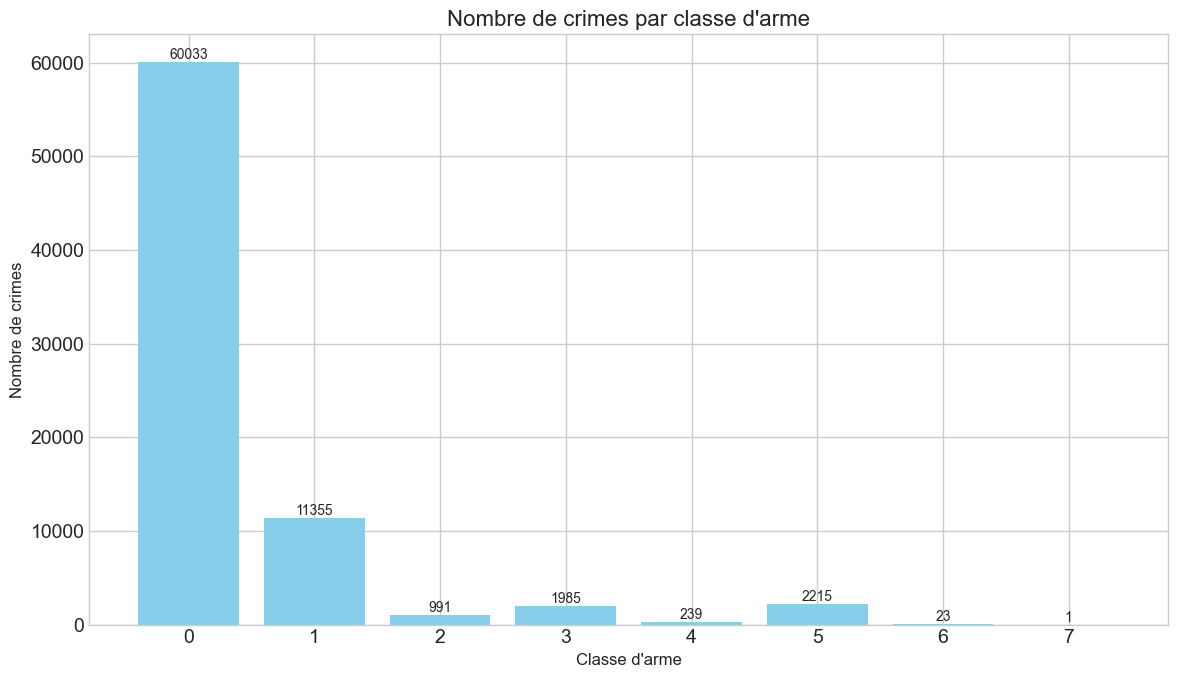

In [41]:
# 1. Compter le nombre d'occurrences pour chaque classe d'arme
# .sort_index() est utilisé pour que les classes soient bien dans l'ordre (0, 1, 2, ...)
weapon_class_counts = LA_data_2024['Crime_Weapon_Class'].value_counts().sort_index()

# 2. Créer le graphique
plt.figure(figsize=(12, 7)) # Définit une taille de figure pour une meilleure lisibilité
bars = plt.bar(weapon_class_counts.index, weapon_class_counts.values, color='skyblue')

# 3. Ajouter les titres et les étiquettes (en français)
plt.title("Nombre de crimes par classe d'arme", fontsize=16)
plt.xlabel("Classe d'arme", fontsize=12)
plt.ylabel("Nombre de crimes", fontsize=12)
plt.xticks(weapon_class_counts.index) # S'assure que toutes les classes sont affichées sur l'axe X

# 4. (Optionnel mais recommandé) Ajouter le nombre exact au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center', fontsize=10)


# 5. Afficher le graphique
plt.tight_layout() # Ajuste le graphique pour que tout soit bien visible
plt.show()

La majorité des crimes commis correspondent à la classe 0 "Menace non physique ou arme inconnue (menace verbale, arme non identifiée)". En second viennent les crimes de classe 1 "Force physique et armes factices (mains, poings, pistolets jouets, intimidation)", équivalent à 14.8% de tous les crimes commis et recensés en 2024. Les autres classes de crimes sont peu représentées et ne compte que pour 7% de tous les crimes commis.


## Mappage des types de crimes

In [42]:
# Affiche un tableau avec type de crime unique
crimes_uniques = LA_data_2024['Crm Cd Desc'].unique()
print(crimes_uniques)

['BATTERY - SIMPLE ASSAULT' 'BURGLARY FROM VEHICLE' 'OTHER ASSAULT'
 'BURGLARY' 'TRESPASSING'
 'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)'
 'THEFT PLAIN - PETTY ($950 & UNDER)'
 'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT' 'CRIMINAL HOMICIDE'
 'BIKE - STOLEN' 'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)'
 'INTIMATE PARTNER - SIMPLE ASSAULT' 'VEHICLE - ATTEMPT STOLEN'
 'BRANDISH WEAPON' 'ATTEMPTED ROBBERY' 'VIOLATION OF COURT ORDER'
 'RAPE, FORCIBLE' 'VANDALISM - MISDEAMEANOR ($399 OR UNDER)'
 'VIOLATION OF RESTRAINING ORDER' 'INTIMATE PARTNER - AGGRAVATED ASSAULT'
 'LETTERS, LEWD  -  TELEPHONE CALLS, LEWD'
 'SHOPLIFTING - PETTY THEFT ($950 & UNDER)' 'ROBBERY'
 'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD'
 'THEFT OF IDENTITY' 'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)'
 'PICKPOCKET' 'BOMB SCARE' 'ARSON' 'CONTRIBUTING'
 'EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)' 'THEFT, PERSON'
 'BUNCO, GRAND THEFT' 'BUNCO, PETTY THEFT' 'BATTERY WITH SEXUAL

Classification des crimes par sévérité.

La Hiérarchie de Classification des Crimes
- Classe 12 : Homicides et crimes capitaux contre les enfants
- Classe 11 : Crimes sexuels majeurs (viol, actes sur mineurs)
- Classe 10 : Trafic humain, kidnapping et violences extrêmes contre les forces de l'ordre
- Classe 9 : Vols à main armée (robbery) et agressions physiques graves
- Classe 8 : Crimes à haut risque public (usage d'armes à feu, incendie volontaire)
- Classe 7 : Vols avec effraction et agressions physiques "simples"
- Classe 6 : Vols de véhicules, menaces et harcèlement
- Classe 5 : Vols importants sans violence directe et fraudes graves
- Classe 4 : Vols simples (petty theft) et autres fraudes
- Classe 3 : Vandalisme et atteintes aux mœurs
- Classe 2 : Atteintes à l'ordre public et à l'autorité judiciaire
- Classe 1 : Infractions mineures, incivilités et conduite dangereuse
- Classe 0 : Non classifié ou autre

In [43]:
# Étape 1 : Créer le dictionnaire de classification pour les crimes
classification_crimes = {
    # --- Classe 12: Homicides & Crimes Capitaux contre les Enfants ---
    'CRIMINAL HOMICIDE': 12,
    'CHILD STEALING': 12,

    # --- Classe 11: Crimes Sexuels Majeurs ---
    'RAPE, FORCIBLE': 11,
    'RAPE, ATTEMPTED': 11,
    'LEWD/LASCIVIOUS ACTS WITH CHILD': 11,
    'SEXUAL PENETRATION W/FOREIGN OBJECT': 11,
    'CHILD PORNOGRAPHY': 11,
    'INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)': 11,
    'SODOMY/SEXUAL CONTACT B/W PENIS OF ONE PERS TO ANUS OTH': 11,
    'ORAL COPULATION': 11,
    'SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W/ FRGN OBJ': 11,
    'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)': 11,

    # --- Classe 10: Trafic Humain, Kidnapping & Violences Extrêmes ---
    'HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE': 10,
    'HUMAN TRAFFICKING - COMMERCIAL SEX ACTS': 10,
    'KIDNAPPING': 10,
    'KIDNAPPING - GRAND ATTEMPT': 10,
    'ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER': 10,

    # --- Classe 9: Vols à Main Armée & Agressions Graves ---
    'ROBBERY': 9,
    'ATTEMPTED ROBBERY': 9,
    'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT': 9,
    'INTIMATE PARTNER - AGGRAVATED ASSAULT': 9,
    'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT': 9,
    'PIMPING': 9,

    # --- Classe 8: Usage d'Armes à Feu & Incendies Volontaires ---
    'SHOTS FIRED AT INHABITED DWELLING': 8,
    'SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT': 8,
    'DISCHARGE FIREARMS/SHOTS FIRED': 8,
    'ARSON': 8,
    'TRAIN WRECKING': 8,

    # --- Classe 7: Vols avec Effraction & Agressions Physiques "Simples" ---
    'BURGLARY': 7,
    'BURGLARY, ATTEMPTED': 7,
    'BATTERY - SIMPLE ASSAULT': 7,
    'INTIMATE PARTNER - SIMPLE ASSAULT': 7,
    'OTHER ASSAULT': 7,
    'BATTERY POLICE (SIMPLE)': 7,
    'BATTERY ON A FIREFIGHTER': 7,
    'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT': 7,
    'CHILD NEGLECT (SEE 300 W.I.C.)': 7,
    'CHILD ABANDONMENT': 7,
    'FALSE IMPRISONMENT': 7,

    # --- Classe 6: Vols de Véhicules, Menaces & Harcèlement ---
    'VEHICLE - STOLEN': 6,
    'VEHICLE - ATTEMPT STOLEN': 6,
    'DRIVING WITHOUT OWNER CONSENT (DWOC)': 6,
    'BIKE - STOLEN': 6,
    'VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)': 6,
    'BRANDISH WEAPON': 6,
    'CRIMINAL THREATS - NO WEAPON DISPLAYED': 6,
    'STALKING': 6,
    'EXTORTION': 6,

    # --- Classe 5: Vols Importants sans Violence & Fraudes Graves ---
    'BURGLARY FROM VEHICLE': 5,
    'BURGLARY FROM VEHICLE, ATTEMPTED': 5,
    'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD': 5,
    'SHOPLIFTING-GRAND THEFT ($950.01 & OVER)': 5,
    'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)': 5,
    'THEFT, PERSON': 5,
    'THEFT FROM PERSON - ATTEMPT': 5,
    'PURSE SNATCHING': 5,
    'PICKPOCKET': 5,
    'PICKPOCKET, ATTEMPT': 5,
    'EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)': 5,
    'BUNCO, GRAND THEFT': 5,
    'BUNCO, ATTEMPT': 5,
    'GRAND THEFT / INSURANCE FRAUD': 5,
    'CREDIT CARDS, FRAUD USE ($950.01 & OVER)': 5,
    'DOCUMENT FORGERY / STOLEN FELONY': 5,
    'DRUNK ROLL': 5,
    'DRUNK ROLL - ATTEMPT': 5,
    'TILL TAP - GRAND THEFT ($950.01 & OVER)': 5,
    'DISHONEST EMPLOYEE - GRAND THEFT': 5,

    # --- Classe 4: Vols Simples & Autres Fraudes ---
    'THEFT PLAIN - PETTY ($950 & UNDER)': 4,
    'THEFT PLAIN - ATTEMPT': 4,
    'SHOPLIFTING - PETTY THEFT ($950 & UNDER)': 4,
    'SHOPLIFTING - ATTEMPT': 4,
    'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)': 4,
    'THEFT FROM MOTOR VEHICLE - ATTEMPT': 4,
    'EMBEZZLEMENT, PETTY THEFT ($950 & UNDER)': 4,
    'BUNCO, PETTY THEFT': 4,
    'THEFT OF IDENTITY': 4,
    'CREDIT CARDS, FRAUD USE ($950 & UNDER': 4,
    'COUNTERFEIT': 4,
    'DOCUMENT WORTHLESS ($200.01 & OVER)': 4,
    'DISHONEST EMPLOYEE - PETTY THEFT': 4,
    'THEFT, COIN MACHINE - PETTY ($950 & UNDER)': 4,

    # --- Classe 3: Vandalisme & Atteintes aux Mœurs ---
    'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)': 3,
    'VANDALISM - MISDEAMEANOR ($399 OR UNDER)': 3,
    'BATTERY WITH SEXUAL CONTACT': 3,
    'INDECENT EXPOSURE': 3,
    'LEWD CONDUCT': 3,
    'PEEPING TOM': 3,
    'PANDERING': 3,
    'CHILD ANNOYING (17YRS & UNDER)': 3,
    'CRUELTY TO ANIMALS': 3,
    'TELEPHONE PROPERTY - DAMAGE': 3,
    'THROWING OBJECT AT MOVING VEHICLE': 3,

    # --- Classe 2: Atteintes à l'Ordre Public & à la Justice ---
    'VIOLATION OF COURT ORDER': 2,
    'VIOLATION OF RESTRAINING ORDER': 2,
    'VIOLATION OF TEMPORARY RESTRAINING ORDER': 2,
    'RESISTING ARREST': 2,
    'TRESPASSING': 2,
    'DISTURBING THE PEACE': 2,
    'FALSE POLICE REPORT': 2,
    'CONTEMPT OF COURT': 2,
    'INCITING A RIOT': 2,
    'CONSPIRACY': 2,
    'SEX OFFENDER REGISTRANT OUT OF COMPLIANCE': 2,
    'DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 & UNDER': 2,
    'DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01': 2,
    'UNAUTHORIZED COMPUTER ACCESS': 2,
    'REPLICA FIREARMS(SALE,DISPLAY,MANUFACTURE OR DISTRIBUTE)': 2,

    # --- Classe 1: Infractions Mineures & Incivilités ---
    'THREATENING PHONE CALLS/LETTERS': 1,
    'LETTERS, LEWD  -  TELEPHONE CALLS, LEWD': 1,
    'BOMB SCARE': 1,
    'PROWLER': 1,
    'FAILURE TO YIELD': 1,
    'RECKLESS DRIVING': 1,
    'OTHER MISCELLANEOUS CRIME': 1,
    'CONTRIBUTING': 1,
    'DRUGS, TO A MINOR': 1,
}

# Étape 2 : Appliquer le mappage pour créer la nouvelle colonne

LA_data_2024['Crime_Type_Class'] = LA_data_2024['Crm Cd Desc'].map(classification_crimes)

# Étape 3 : Gérer les valeurs non classifiées en les mettant à 0
# et convertir la colonne en type entier
LA_data_2024['Crime_Type_Class'] = LA_data_2024['Crime_Type_Class'].fillna(0).astype(int)

# Étape 4 : Vérifier le résultat
print("Aperçu de la nouvelle classification des crimes :")
print(LA_data_2024[['Crm Cd Desc', 'Crime_Type_Class']].head(10))

print("\nRépartition des crimes par classe :")
print(LA_data_2024['Crime_Type_Class'].value_counts().sort_index())

Aperçu de la nouvelle classification des crimes :
                                         Crm Cd Desc  Crime_Type_Class
0                           BATTERY - SIMPLE ASSAULT                 7
1                           BATTERY - SIMPLE ASSAULT                 7
2                              BURGLARY FROM VEHICLE                 5
3                                      OTHER ASSAULT                 7
4                              BURGLARY FROM VEHICLE                 5
5                                           BURGLARY                 7
6                                        TRESPASSING                 2
7  VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...                 3
8                           BATTERY - SIMPLE ASSAULT                 7
9                 THEFT PLAIN - PETTY ($950 & UNDER)                 4

Répartition des crimes par classe :
Crime_Type_Class
1      1734
2      2731
3      8797
4     18151
5     21605
6      3954
7     12230
8       241
9      6603
10     

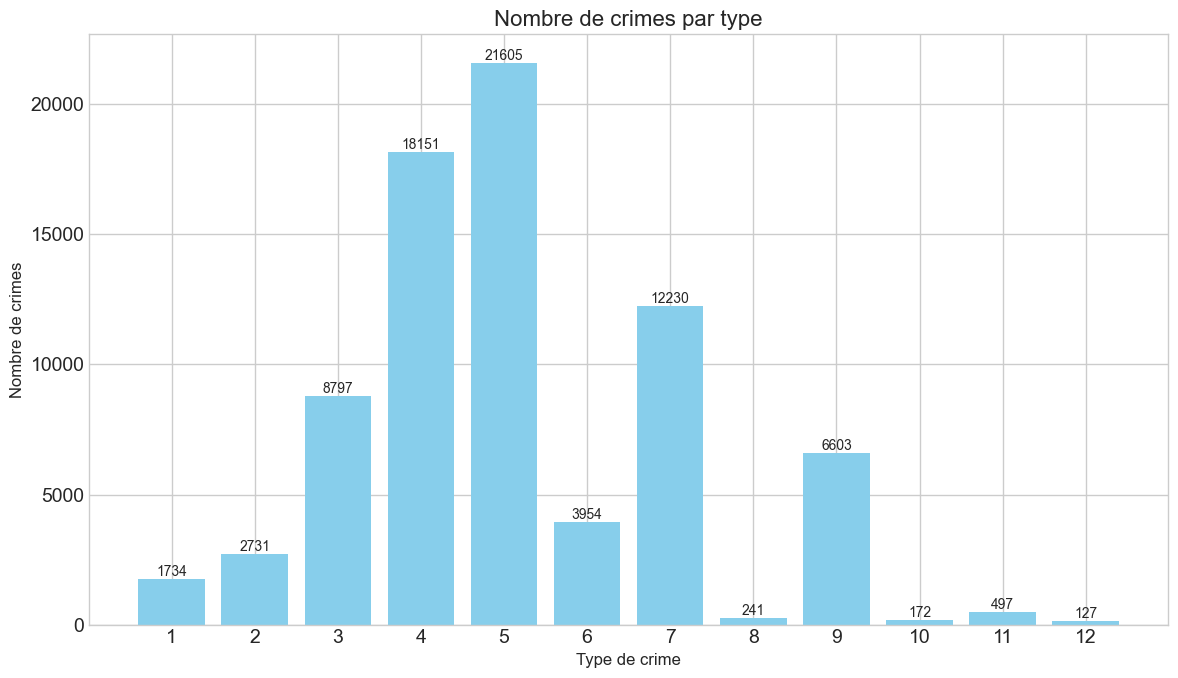

In [44]:
# 1. Compter le nombre d'occurrences pour chaque classe d'arme
# .sort_index() est utilisé pour que les classes soient bien dans l'ordre (0, 1, 2, ...)
crimes_count = LA_data_2024['Crime_Type_Class'].value_counts().sort_index()

# 2. Créer le graphique
plt.figure(figsize=(12, 7)) # Définit une taille de figure pour une meilleure lisibilité
bars = plt.bar(crimes_count.index, crimes_count.values, color='skyblue')

# 3. Ajouter les titres et les étiquettes (en français)
plt.title("Nombre de crimes par type", fontsize=16)
plt.xlabel("Type de crime", fontsize=12)
plt.ylabel("Nombre de crimes", fontsize=12)
plt.xticks(crimes_count.index) # S'assure que toutes les classes sont affichées sur l'axe X

# 4. (Optionnel mais recommandé) Ajouter le nombre exact au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center', fontsize=10)


# 5. Afficher le graphique
plt.tight_layout() # Ajuste le graphique pour que tout soit bien visible
plt.show()

Les crimes les plus fréquemment commis sont les crimes de classe 5 "vols importants sans violence directe et fraudes grave". En seconde position viennent les crimes de classe 4 "vols simples et autres fraudes", et finallement en 3 ème position viennent les crimes de classe 7 "vols avec effraction et agressions physiques simples".

Pour rappel, voici la hiérarchie de classification des crimes :
- Classe 12 : Homicides et crimes capitaux contre les enfants
- Classe 11 : Crimes sexuels majeurs (viol, actes sur mineurs)
- Classe 10 : Trafic humain, kidnapping et violences extrêmes contre les forces de l'ordre
- Classe 9 : Vols à main armée (robbery) et agressions physiques graves
- Classe 8 : Crimes à haut risque public (usage d'armes à feu, incendie volontaire)
- Classe 7 : Vols avec effraction et agressions physiques "simples"
- Classe 6 : Vols de véhicules, menaces et harcèlement
- Classe 5 : Vols importants sans violence directe et fraudes graves
- Classe 4 : Vols simples (petty theft) et autres fraudes
- Classe 3 : Vandalisme et atteintes aux mœurs
- Classe 2 : Atteintes à l'ordre public et à l'autorité judiciaire
- Classe 1 : Infractions mineures, incivilités et conduite dangereuse
- Classe 0 : Non classifié ou autre

## Mappage de l'ethnie des victimes
	
Descent Code selon glossaire fourni par la police :

A - Other Asian B - Black C - Chinese D - Cambodian F - Filipino G - Guamanian H - Hispanic/Latin/Mexican I - American Indian/Alaskan Native J - Japanese K - Korean L - Laotian O - Other P - Pacific Islander S - Samoan U - Hawaiian V - Vietnamese W - White X - Unknown Z - Asian Indian

Classification selon Gemini. J'ai mis les blancs comme valeur supérieure car ils ont plus de probabilité de vivre dans des zones plus chères. Cette classification permet de créer une classification numérique nécessaire au bon fonctionnement Cela permetra à l'algorithme de régression linéaire.

La Hiérarchie de Classification des ethnies.
- Classe 5 : Blanc (White)
- Classe 4 : Asiatique (Chine, Japon, Corée)
- Classe 3 : Hispanique et autres groupes asiatiques
- Classe 2 : Noir (Black), Amérindien et Insulaire du Pacifique
- Classe 1 : Autre (Other)
- Classe 0 : Inconnu (Unknown) ou non spécifié

In [45]:
# Les différentes ethnies uniques présentes dans le jeu de données.
race_uniques = LA_data_2024['Vict Descent'].unique()
print(race_uniques)

['B' 'O' 'W' 'X' 'H' 'C' 'F' 'J' 'A' 'K' 'D' 'V' 'Z' 'I' 'P' 'U' 'S' 'L'
 'G' nan]


In [46]:
# Étape 1 : Créer le dictionnaire de classification basé sur le code de descendance
# W = White, H = Hispanic, B = Black, etc.
classification_ethnie = {
    # --- Classe 5: Blanc ---
    'W': 5,

    # --- Classe 4: Asiatique (Chine, Japon, Corée) ---
    'C': 4, 
    'J': 4,
    'K': 4,

    # --- Classe 3: Hispanique et autres groupes asiatiques ---
    'H': 3,
    'A': 3, # Other Asian
    'F': 3, # Filipino
    'V': 3, # Vietnamese
    'L': 3, # Laotian
    'Z': 3, # Asian Indian
    'D': 3, # Cambodian

    # --- Classe 2: Noir, Amérindien et Insulaire du Pacifique ---
    'B': 2,
    'I': 2, # American Indian/Alaskan Native
    'P': 2, # Pacific Islander
    'S': 2, # Samoan
    'U': 2, # Hawaiian
    'G': 2, # Guamanian

    # --- Classe 1: Autre ---
    'O': 1,

    # --- Classe 0: Inconnu ---
    'X': 0,
}

# Étape 2 : Appliquer le mappage pour créer la nouvelle colonne "Victim_race"

LA_data_2024['Victim_race'] = LA_data_2024['Vict Descent'].map(classification_ethnie)

# Étape 3 : Gérer les valeurs non classifiées (comme 'nan') en les mettant à 0
# et convertir la colonne en type entier pour un format plus propre
LA_data_2024['Victim_race'] = LA_data_2024['Victim_race'].fillna(0).astype(int)

# Étape 4 : Vérifier le résultat
print("Aperçu de la nouvelle classification des victimes :")
print(LA_data_2024[['Vict Descent', 'Victim_race']].head(10))

print("\nRépartition des victimes par classe :")
print(LA_data_2024['Victim_race'].value_counts().sort_index())

Aperçu de la nouvelle classification des victimes :
  Vict Descent  Victim_race
0            B            2
1            O            1
2            W            5
3            B            2
4            W            5
5            O            1
6            X            0
7            W            5
8            H            3
9            O            1

Répartition des victimes par classe :
Victim_race
0     3080
1     6441
2    11881
3    31762
4     2688
5    20990
Name: count, dtype: int64


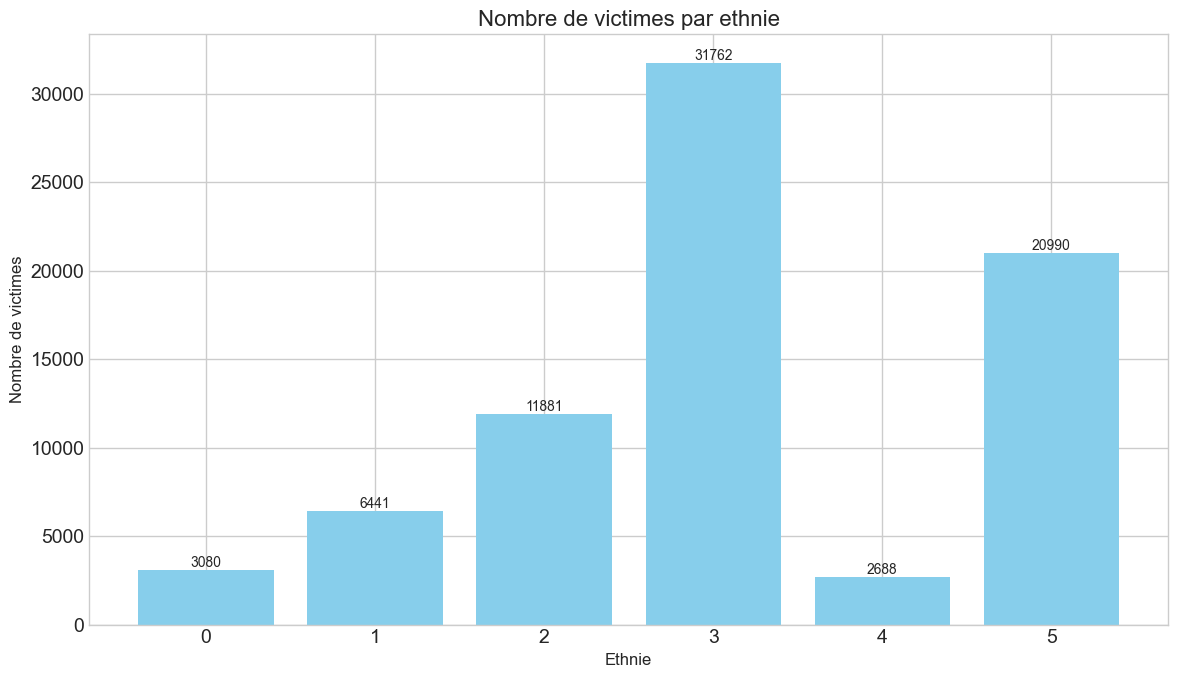

In [47]:
# 1. Compter le nombre d'occurrences pour chaque classe d'arme
# .sort_index() est utilisé pour que les classes soient bien dans l'ordre (0, 1, 2, ...)
victime_race_counts = LA_data_2024['Victim_race'].value_counts().sort_index()

# 2. Créer le graphique
plt.figure(figsize=(12, 7)) # Définit une taille de figure pour une meilleure lisibilité
bars = plt.bar(victime_race_counts.index, victime_race_counts.values, color='skyblue')

# 3. Ajouter les titres et les étiquettes (en français)
plt.title("Nombre de victimes par ethnie", fontsize=16)
plt.xlabel("Ethnie", fontsize=12)
plt.ylabel("Nombre de victimes", fontsize=12)
plt.xticks(victime_race_counts.index) # S'assure que toutes les classes sont affichées sur l'axe X

# 4. (Optionnel mais recommandé) Ajouter le nombre exact au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center', fontsize=10)


# 5. Afficher le graphique
plt.tight_layout() # Ajuste le graphique pour que tout soit bien visible
plt.show()

Les les groupes ethniques les plus fréquemment victimes de crimes dans notre jeu de données sont en premier lieu les "Hispaniques et autres groupes asiatiques", suivi par les Blancs, puis par les Noirs en 3 ème position. 

## Mappage du genre de la victime
Le genre des victimes est au format charactère (M, F). Il faut le convertir au format numérique pour qu'il puisse être lu par le modèle de régression linéaire. Je classifie donc M = 0, F = 1 et crée une nouvelle variable "Victim_Gender_Num".


In [48]:
# Créer un dictionnaire pour le mappage
# M (Male) sera 0, F (Female) sera 1
gender_mapping = {'M': 0, 'F': 1}

# Appliquer le mappage à la colonne "Vict Sex" pour créer la nouvelle colonne
LA_data_2024['Victim_Gender_Num'] = LA_data_2024['Vict Sex'].map(gender_mapping)

# Afficher les premières lignes pour vérifier le résultat
print(LA_data_2024[['Vict Sex', 'Victim_Gender_Num']].head())

  Vict Sex  Victim_Gender_Num
0        F                1.0
1        M                0.0
2        M                0.0
3        M                0.0
4        M                0.0


## Abandon de la variable Modus Operanti
Je décide volontairement de ne pas inclure la variable modus operanti. Celle-ci contient les codes pour le mode opératoire des criminels et selon le document mis à disposition par la police il y a 19 pages de codes qui détaillent chaque type de mode opératoire des criminels. Je pense que cette variable n'améliorera pas beaucoup plus les futurs modèles car il y a trop de possibilités en plus qu'il est possible d'avoir plusieurs codes pour un même crime. https://data.lacity.org/api/views/2nrs-mtv8/files/4591b6bf-5846-4de0-9fb0-8780a77a036c?download=true&filename=MO_CODES_Numerical_20191119.pdf

Par exemple, le modus operanti peut inclure :
- Le point d'entrée (pour les cambriolages) : Fenêtre forcée, porte déverrouillée, toit, etc.
- Le type de force utilisée : Arme à feu, couteau, force physique, menace verbale.
- Les actions du suspect : A ligoté la victime, a agi en état d'ébriété, a porté un déguisement, a coupé les lignes téléphoniques.
- Le type de propriété volée : Argent, bijoux, appareils électroniques, véhicules.
- Des comportements spécifiques : A commis des actes de vandalisme gratuits, a mangé sur les lieux du crime, a laissé une "signature"

Et à pour objectif de comprendre la psychologie du criminel (profilage), de repérer les shémas, d'orienter sur les prochaines actions d'un criminel.

Ces caractéristiques sortent du cadre de cette analyse.

## Suppression des colonnes inutiles
Suppression des variables initialement non mappées, des variables à code, et des variables temporelles ainsi que des variables résultant de la création de graphiques.

In [49]:
colonnes_a_supprimer = [
    "AREA_x", "AREA NAME", "Crm Cd", "Crm Cd Desc", "Mocodes", "Premis Cd",
    "Weapon Desc", "Crm Cd 1", "AREA_y", "Vict Sex", "Vict Descent", "DATE_TIME_OCC", "count",
    "hour", "time_slot", "income_quartile", "year", "day_of_week", "year_month"
]

LA_data_2024 = LA_data_2024.drop(columns=colonnes_a_supprimer)

## Analyse de collinéarité 
### Matrice de corrélation

<Axes: >

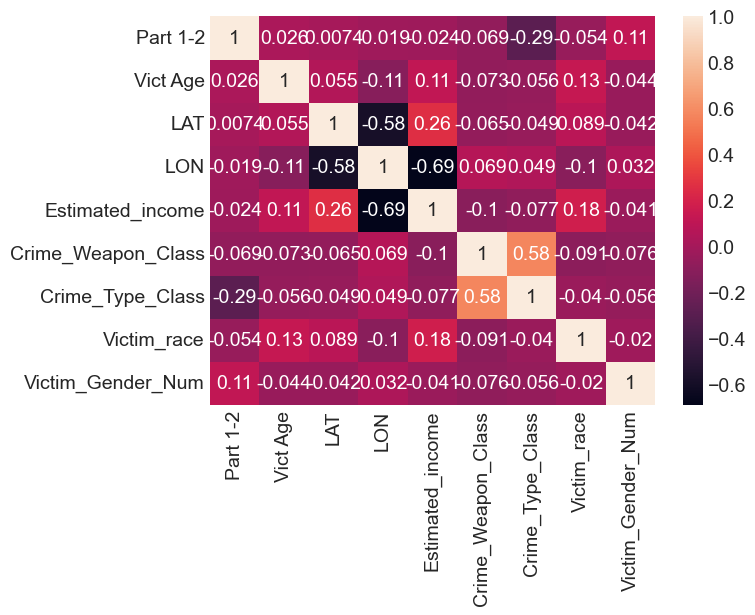

In [50]:
correlation_matrix = LA_data_2024.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True)

Nous notons qu'il n'y a pas de collinéarité entre les variables, pas même entre l'ethnie de la victime et du revenu moyen par foyer. Il existe une corrélation négative entre la longitude et le revenu moyen par foyer.

### Analyse des variables restantes

Voyons quelles colonnes il nous reste. Il ne devrait que rester des colonnes numériques.

In [51]:
print(LA_data_2024)

       Part 1-2  Vict Age      LAT       LON  Estimated_income  \
0             2        22  34.0944 -118.3125             59393   
1             2        58  34.1876 -118.6070            120000   
2             1        49  34.1939 -118.5098             85000   
3             2        50  34.1053 -118.3159             59393   
4             1        37  34.1874 -118.6035            120000   
...         ...       ...      ...       ...               ...   
76837         1        42  34.0531 -118.2512             60473   
76838         1        36  34.0617 -118.3066             58000   
76839         1        46  33.9469 -118.3703             90000   
76840         1        29  34.0675 -118.2240             56001   
76841         1        70  34.0215 -118.2868             55000   

       Crime_Weapon_Class  Crime_Type_Class  Victim_race  Victim_Gender_Num  
0                       1                 7            2                1.0  
1                       1                 7        

Il ne nous reste que des variables numériques.



## Analyse des not a number (NaN) et imputation/suppression

Maintenant, analysons la proportion de valeurs qui ne sont pas des nombres (NaN : not a number) afin de décider si nous les imputons ou les supprimons.
Je suis d'avis que si il n'y en a pas trop nous supprimons la ligne complète à chaque fois qu'il y a un NaN.

À chaque fois qu'il y a une ligne blanche dans une colonne c'est qu'il y a un NaN.

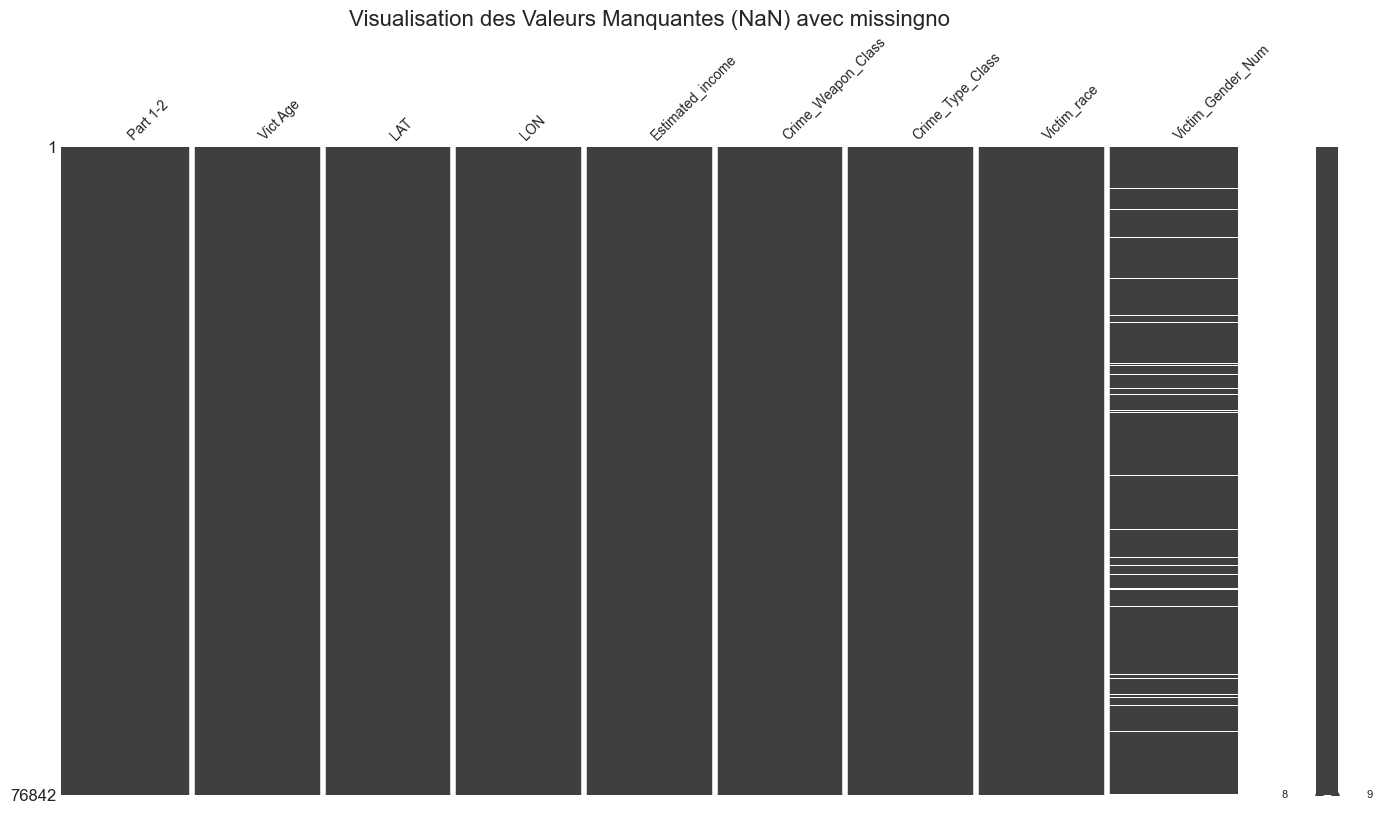

In [52]:
# Créer la matrice de visualisation des NaN
# Chaque ligne noire représente des données présentes.
# Chaque ligne blanche représente une valeur manquante (NaN).
msno.matrix(LA_data_2024, figsize=(15, 8), fontsize=10)

plt.title("Visualisation des Valeurs Manquantes (NaN) avec missingno", fontsize=16)
plt.show()

Nous constatons que seul la variable "Victim_Gender_Num" contient des NaNs. Leur fréquence est relativement faible.
Je prend la décision de retirer ces lignes.

In [53]:
# Supprime toutes les lignes contenant au moins une valeur NaN
LA_data_2024.dropna(inplace=True)


# Régréssion linéaire

## 🧱 Division en ensembles d'entraînement et de test

Maintenant, divisons les données en un ensemble d'entraînement et un ensemble de test. Nous allons entraîner notre modèle sur l'ensemble d'entraînement, puis utiliser l'ensemble de test pour évaluer le modèle.

Je prend l'ethnie de la victime comme variable indépendante de réponse (Y) dépendant des autres variables indépendantes (X).

In [54]:
# Garder toutes les colonnes sauf 'Victim_race'
X = LA_data_2024.drop(['Victim_race'],axis='columns')

# Garder seulement la colonne 'Victim_race'
y = LA_data_2024['Victim_race']

Création des ensemble d'entrainement et de test.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [56]:
from sklearn import metrics

def print_evaluate(true, predicted):  
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Square', r2_square)
    print('__________________________________')
    
def evaluate(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    return mae, mse, rmse, r2_square

# Préparation des données pour la régression linéaire

> La régression linéaire a été étudiée en profondeur, et il existe beaucoup de littérature sur la manière dont vos données doivent être structurées pour tirer le meilleur parti du modèle.

- **Hypothèse de linéarité.** La régression linéaire suppose que la relation entre vos variables d'entrée et de sortie est linéaire. Elle ne prend pas en charge autre chose. Cela peut sembler évident, mais il est bon de s'en souvenir lorsque vous avez de nombreuses variables. Vous devrez peut-être transformer les données pour rendre la relation linéaire (par exemple, une transformation logarithmique pour une relation exponentielle).

- **Éliminer le bruit.** La régression linéaire suppose que vos variables d'entrée et de sortie ne sont pas bruitées. Envisagez d'utiliser des opérations de nettoyage des données qui vous permettent de mieux exposer et clarifier le signal dans vos données. C'est particulièrement important pour la variable de sortie, et vous voudrez éliminer les valeurs aberrantes (outliers) dans la variable de sortie (y) si possible.

- **Éliminer la collinéarité.** La régression linéaire surajustera vos données lorsque vos variables d'entrée sont fortement corrélées. Envisagez de calculer les corrélations par paires de vos données d'entrée et de supprimer les corrélations les plus élevées.

- **Distributions gaussiennes.** La régression linéaire fera des prédictions plus fiables si vos variables d'entrée et de sortie ont une distribution gaussienne. Vous pouvez obtenir des avantages en utilisant des transformations (par exemple, fonction logarithmique) sur vos variables pour rendre leur distribution plus proche de celle d'une gaussienne.

- **Redimensionner les entrées:** La régression linéaire fera souvent des prédictions plus fiables si vous redimensionnez les variables d'entrée en utilisant la standardisation ou la normalisation.

## Analyse de la linéarité
Etant donnée que ma variable de réponse est catégorielle (catégories ethniques) je ne peux pas créer un nuage de points pour voir si celui-ci suit une ligne. En contre-partie, je peux plotter graphiquement les variables indépendantes en fonction de la variable dépendante. Comme suit. 

In [57]:
# LA_data_2024['Victim_race'] = LA_data_2024['Victim_race'].astype('category')

Génération des nuages de points pour chaque variable indépendante...


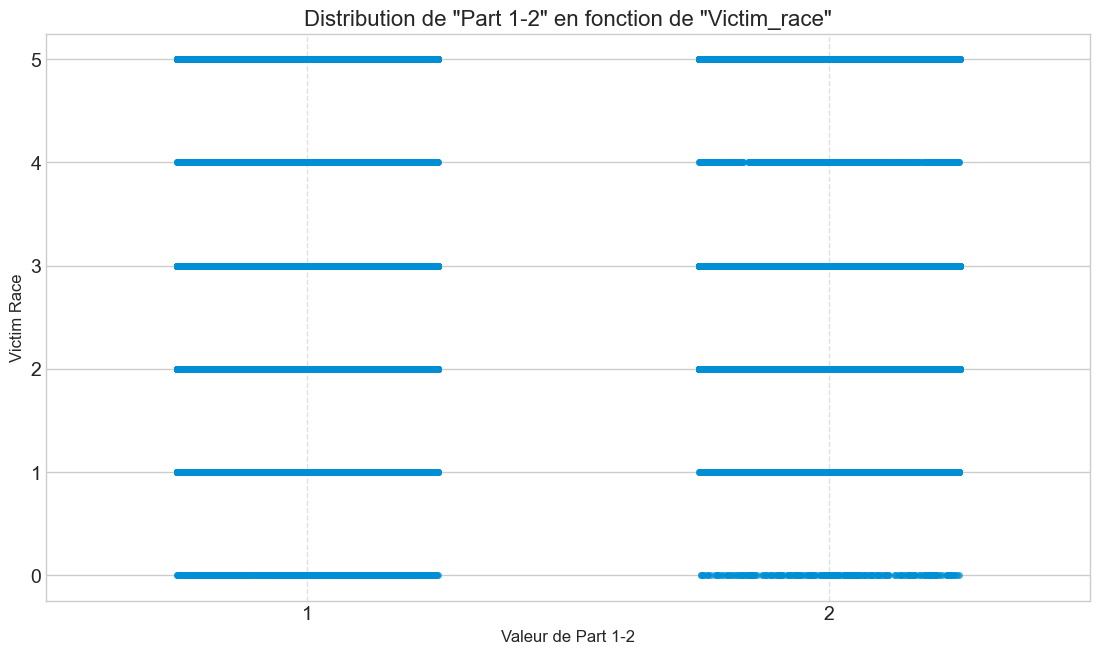

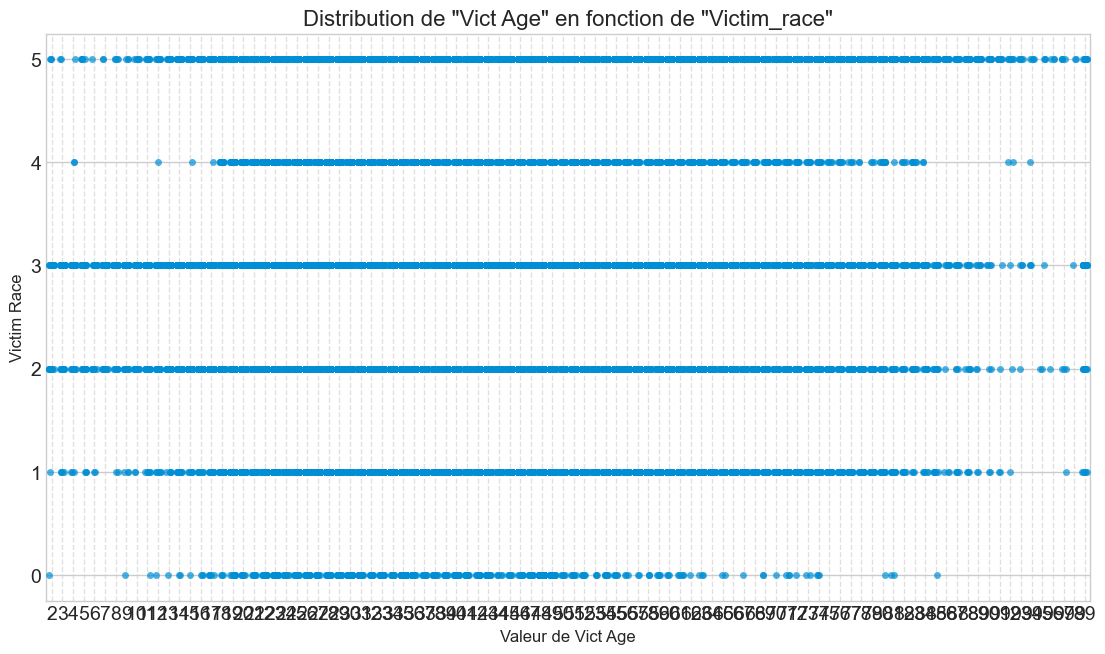

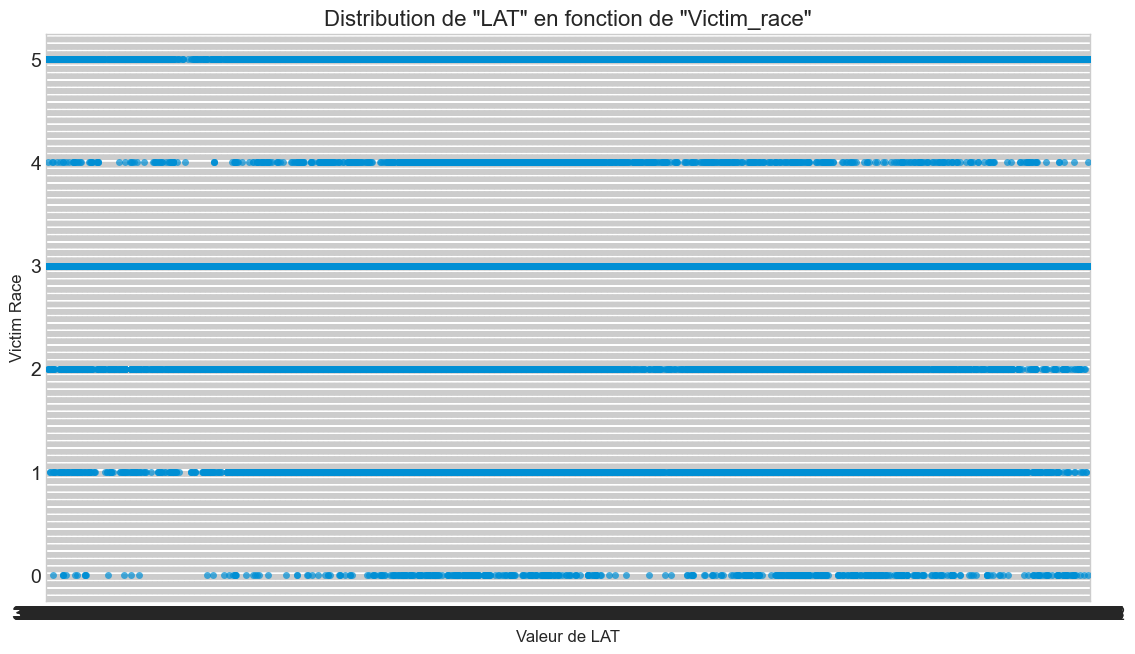

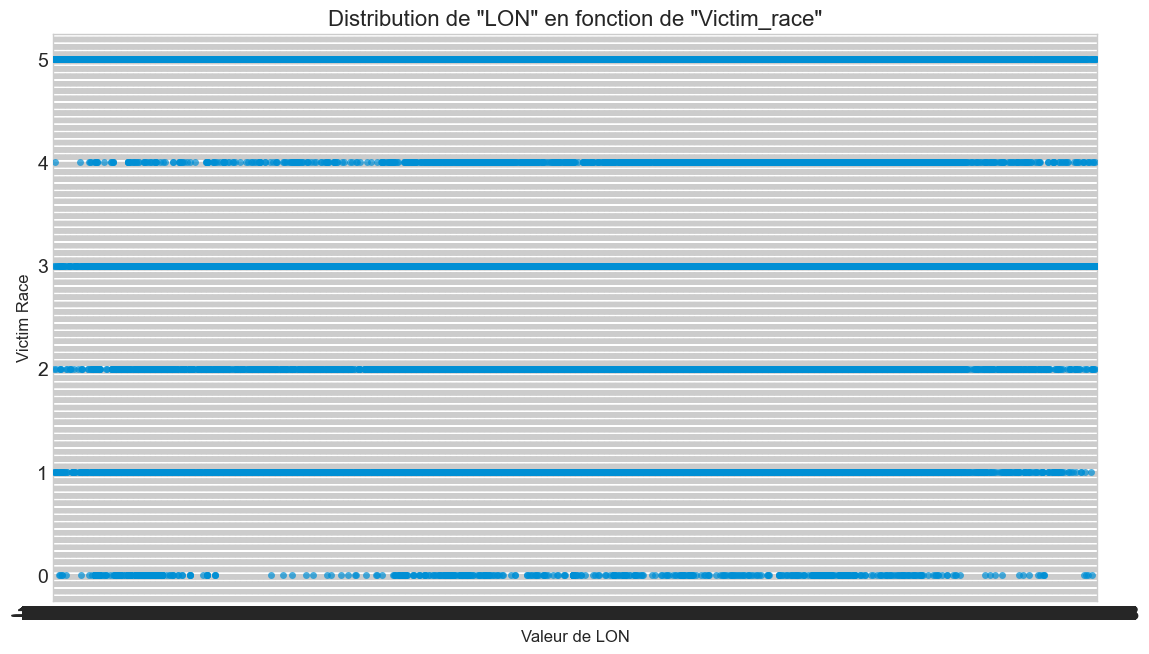

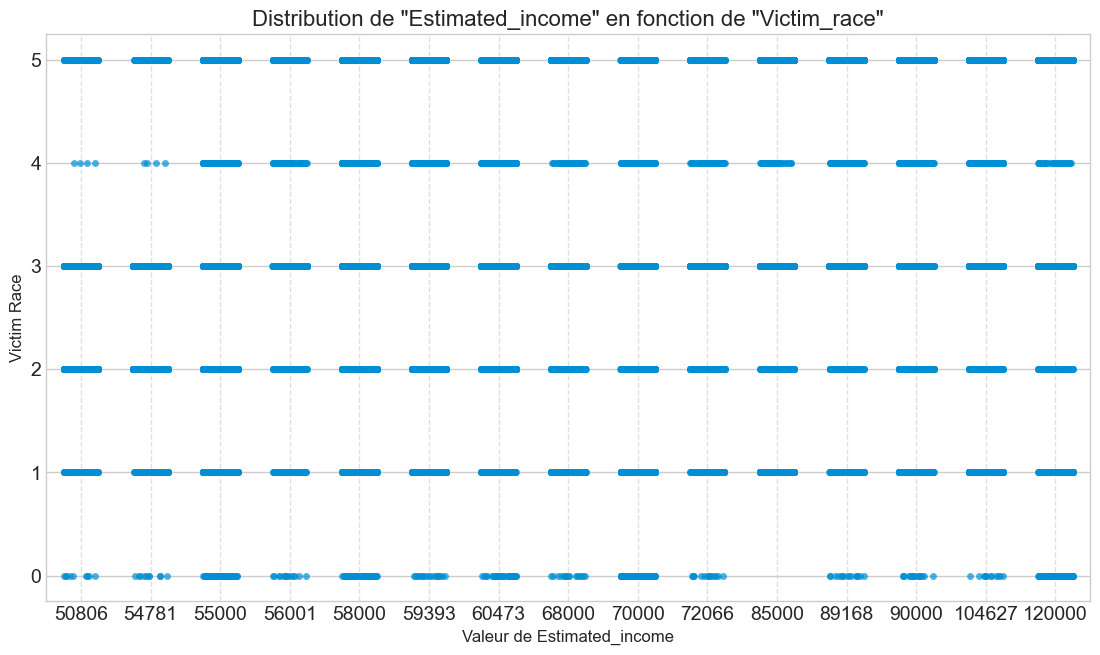

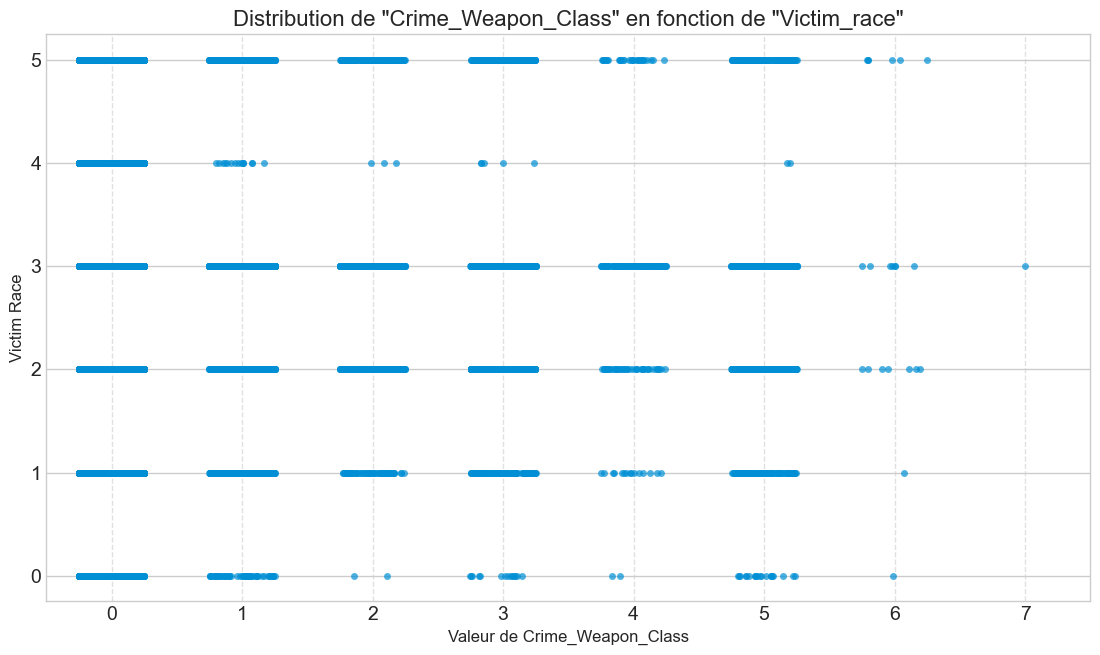

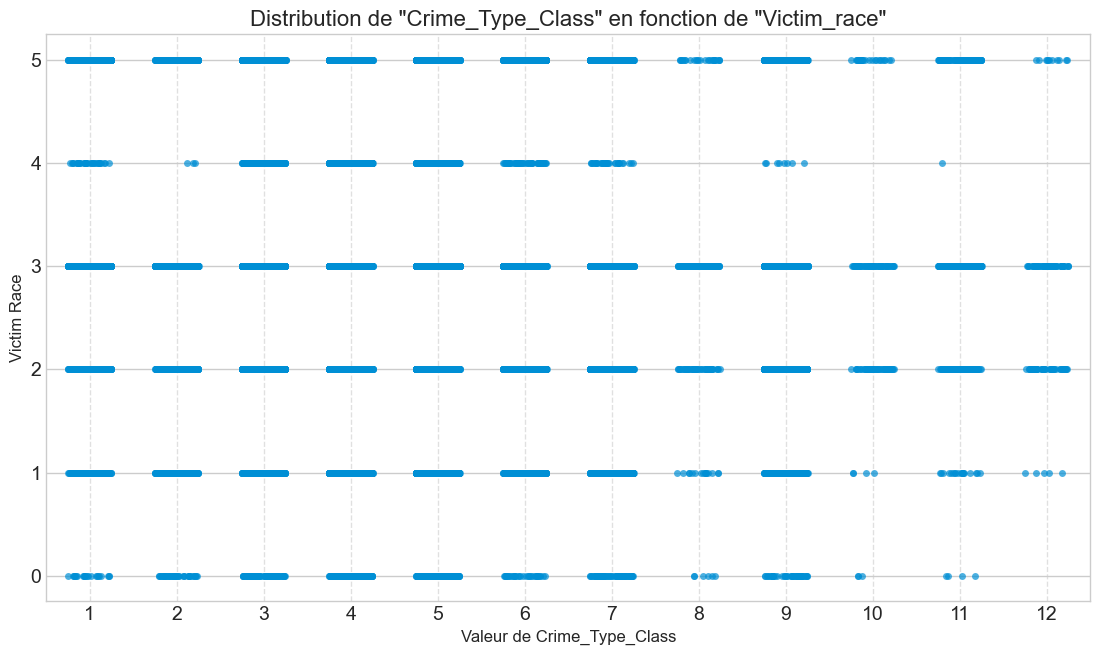

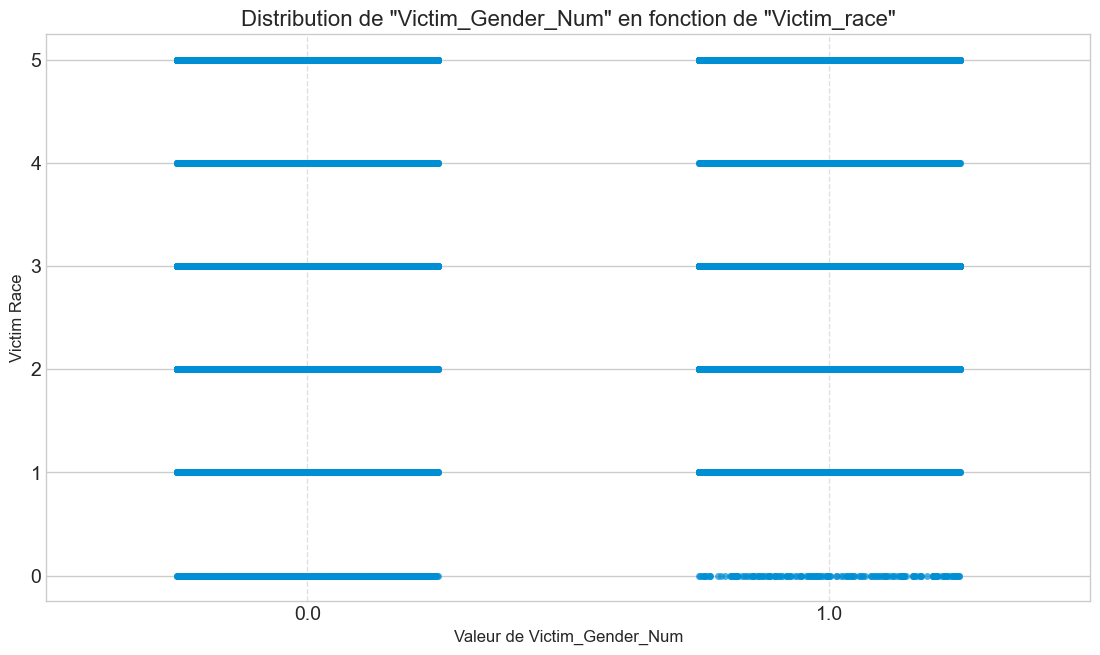

In [58]:
# Nous allons boucler sur chaque variable indépendante (chaque colonne de X)
# et créer un graphique pour chacune.

print("Génération des nuages de points pour chaque variable indépendante...")

for column in X.columns:
    plt.figure(figsize=(12, 7)) # Crée une nouvelle figure pour chaque graphique
    
    # Utilisation de seaborn pour un rendu plus esthétique, surtout avec des catégories
    # stripplot est une bonne alternative au scatterplot pour voir la distribution
    sns.stripplot(x=X[column], y=y, jitter=0.25, size=5, alpha=0.7)
    
    plt.title(f'Distribution de "{column}" en fonction de "Victim_race"', fontsize=16)
    plt.xlabel(f'Valeur de {column}', fontsize=12)
    plt.ylabel('Victim Race', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

Nous pouvons constater que les valeurs des variables indépendantes sont réparties de façon uniforme en fonction de la variable de réponse (Victime_race). Ceci nous indique que la linéarité est non existante. Cela risque de poser soucis pour la phase de modélisation, car l'hypothèse de linéarité des variables est essentielle.

## Standardisation des données

Standardisation des données moyenne = 0, écart standard = 1 pour chaque variable du jeu de données d'entrainement. Ceci permet de donner un poids identique à chaque variable. Autrement, des variables avec des valeurs moyennes et écart-types plus élevés pourraient prédominer sur les autres lors de la modélisation.

In [59]:
# Standardisation
pipeline = Pipeline([
    ('std_scalar', StandardScaler())
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

## Modèle de régression linéaire

In [60]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

LinearRegression()

## Évaluation du modèle 1

Évaluons le modèle en examinant ses coefficients.

In [61]:
# print the intercept
print(lin_reg.intercept_)

3.230130258791033


In [62]:
coeff_df = pd.DataFrame(lin_reg.coef_, X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Part 1-2,-0.083097
Vict Age,0.082128
LAT,0.069596
LON,0.076316
Estimated_income,0.189827
Crime_Weapon_Class,-0.088014
Crime_Type_Class,-0.061463
Victim_Gender_Num,-0.018603


**Question**: Comment interprétez-vous ces coefficients?

L'intercept est de 3.23, c'est à dire que si toutes les variables indépendantes sont à 0 la victime sera initialement Hispanique ou d'autres groupes asiatiques.
Nous voyons que l'augmentation de 1 LAT augmente la valeur de Victim_race de 0.069596 au coefficient de 3.23.
De manière similaire, l'augmentation de 1 LON augmente la valeur de Victim_race de 0.076316.
Ces deux résultats ne font pas de sens. Je pense que cela est dû au fait qu'il y a beaucoup plus de quartiers recensés au Nord et à l'Est de Los Angeles que de quartier au Sud-Ouest. Ceci se voit bien lorsque nous regardons la carte "carte_crimes_LA_coloree.html". La grande majorité des quarties inclus dans le jeu de données sont au nord et seul une bande de quartier est recensée au sud.
Je prend donc la décision de retirer les caractéristiques (variables) LAT et LON. et de relancer le modèle de régression linéaire.

<details>
<summary>Aide</summary>
N'oubliez pas la standardisation faite au début sur les données!

Pour retrouver les écarts types utilisés pour la standardisation: pipeline.named_steps['std_scalar'].scale_
</details>

## Évaluation du modèle 2

In [63]:
# Garder toutes les colonnes sauf 'Estimated_income'
X = LA_data_2024.drop(['Victim_race', 'LAT', 'LON'],axis='columns')

# Garder seulement la colonne 'Estimated_income'
y = LA_data_2024['Victim_race']

# Partitionnage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardisation
pipeline = Pipeline([
    ('std_scalar', StandardScaler())
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

LinearRegression()

In [64]:
# print the intercept
print(lin_reg.intercept_)

3.2301302587910294


In [65]:
coeff_df = pd.DataFrame(lin_reg.coef_, X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Part 1-2,-0.085463
Vict Age,0.080058
Estimated_income,0.154280
Crime_Weapon_Class,-0.089676
Crime_Type_Class,-0.064399
Victim_Gender_Num,-0.020827


Ici, la victime est toujours initialement Hispanique ou d'autres groupes asiatiques, et pour chaque augmentation de 1 $ dans le revenu moyen estimé par foyer, la valeur prédite augmente de 0.154280.
Il faut retransformer pour obtenir les coefficient en unités d'origine afin d'annuler l'effet de la standardisation.

### Traduction des coefficients en unités d'origine

In [66]:
interpret_df = pd.DataFrame(coeff_df["Coefficient"]/pipeline.named_steps['std_scalar'].scale_)

interpret_df

,Coefficient
Part 1-2,-0.174228
Vict Age,0.005269
Estimated_income,0.000009
Crime_Weapon_Class,-0.088149
Crime_Type_Class,-0.033196
Victim_Gender_Num,-0.041684


> Interprétation des coefficients:
- Ceteris Paribus, si le crime est plus grave (catégorie 2), la classe ethnique prédite est réduite de 0.174288, ce qui correspond à la variable ayant le plus d'impact par niveau (2 niveaux).
- "", chaque année en plus à l'âge de la victime correspond à une hausse de 0.005269 de la variable de réponse.
- "", chaque dollars en plus augment la classe ethnique de la victime de 0.000009.
- "", chaque catégorie de dangerosité en plus de l'arme du crime correspond à une baisse dans la variable de réponse de 0.088149. Cette variable indépendante correspond à celle pouvant le plus affecter la variable de réponse.
- Idem pour la catégorie de crime, avec une baisse de -0.033196 de la variable de réponse pour chaque hausse de niveau de cette classe.
-  si la victime est une femme, la classe ethnique prédite est réduite de 0.041684.

## Prédictions de notre modèle

Nous constatons que le modèle est très mauvais à prédire l'ethnie de la victime. En effet, les prédictions oscillent entre 2.5 e 4 tandis que les valeurs réelles sont réparties sur les 5 classes.

In [67]:
pred = lin_reg.predict(X_test)

In [68]:
pd.DataFrame({'True Values': y_test, 'Predicted Values': pred}).hvplot.scatter(x='True Values', y='Predicted Values')

:Scatter   [True Values]   (Predicted Values)

**Residual Histogram**

In [69]:
pd.DataFrame({'Error Values': (y_test - pred)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

In [70]:
# Statistiques sur les erreurs de prédictions
abs(y_test-pred).describe()

count    22341.000000
mean         1.010020
std          0.788910
min          0.000022
25%          0.247252
50%          0.969167
75%          1.655814
max          3.964716
Name: Victim_race, dtype: float64

Nous observons que les erreurs de prédictions sont en moyenne de 1.01 avec un quartile inférieur à 0.23 et un quartile supérieur à 1.66. Nous pouvons conclure que le modèle n'est absolument pas utile pour prédire la classe ethnique de la victime. 

## Métriques d'évaluation de la régression
Je me base sur la métrique du R2 score qui est la version “normalisée” de la MSE (Mean Squared Error). Plus le R2 score est élevé (max = 100%) et plus le modèle est performant. Nous pouvons constater que le R2 score de notre modèle est de 0.032 tant sur l'échantillon d'entraînement que celui de test, ce qui nous porte à conclure que le modèle est absolument inutile pour prédire la classe ethnique de la victime en fonction des autres variables. 

In [71]:
test_pred = lin_reg.predict(X_test)
train_pred = lin_reg.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

results_df = pd.DataFrame(data=[["Linear Regression", *evaluate(y_test, test_pred)]], 
                          columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square'])

Test set evaluation:
_____________________________________
MAE: 1.0100203661912142
MSE: 1.6424917680154882
RMSE: 1.281597350190569
R2 Square 0.03765916930146107
__________________________________
Train set evaluation:
_____________________________________
MAE: 1.0138687553466814
MSE: 1.6648302113560038
RMSE: 1.2902829966158602
R2 Square 0.03606326959774431
__________________________________


# Random Forest Regressor
Est-ce qu'un modèle non-linéaire plus complexe aurait fait mieux?

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=1000)
rf_reg.fit(X_train, y_train)

test_pred = rf_reg.predict(X_test)
train_pred = rf_reg.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)

print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

results_df_2 = pd.DataFrame(data=[["Random Forest Regressor", *evaluate(y_test, test_pred)]], 
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square'])
results_df = pd.concat([results_df, results_df_2], ignore_index=True)


Test set evaluation:
_____________________________________
MAE: 1.0431623751988335
MSE: 1.7991432182327354
RMSE: 1.3413214447822472
R2 Square -0.054123383078901854
__________________________________
Train set evaluation:
_____________________________________
MAE: 0.7743916723341012
MSE: 1.0606645470990206
RMSE: 1.0298856961328382
R2 Square 0.38587520300255496
__________________________________


In [73]:
results_df

,Model,MAE,MSE,RMSE,R2 Square
0,Linear Regression,1.010020,1.642492,1.281597,0.037659
1,Random Forest Regressor,1.043162,1.799143,1.341321,-0.054123


Conclusion : aucun des deux modèles n'est utile pour prédire la classe ethnique des victimes en fonction des autres variables fournies dans le jeu de données. Ceci était déja à supposer en observant que les variables indépendantes ne respectaient pas l'hypothèse de linéarité.

# PCA - K means

In [74]:
import tarfile
import urllib

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

Vérifions la taille des données;

- Nombre de lignes
- Nombre de colonnes

In [75]:
# Using ndarrays
print(LA_data_2024.shape)

# Using Pandas DataFrame
pd.DataFrame(LA_data_2024).info()

(74468, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 74468 entries, 0 to 76841
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Part 1-2            74468 non-null  int64  
 1   Vict Age            74468 non-null  int64  
 2   LAT                 74468 non-null  float64
 3   LON                 74468 non-null  float64
 4   Estimated_income    74468 non-null  int64  
 5   Crime_Weapon_Class  74468 non-null  int32  
 6   Crime_Type_Class    74468 non-null  int32  
 7   Victim_race         74468 non-null  int32  
 8   Victim_Gender_Num   74468 non-null  float64
dtypes: float64(3), int32(3), int64(3)
memory usage: 4.8 MB


In [76]:
# Supposons que votre DataFrame est LA_data_2024
df = LA_data_2024

# 1. Définir la variable cible (y) que vous voulez prédire
# Remplacez 'Crime_Type_Class' par le nom de votre colonne cible.
colonne_cible = 'Crime_Type_Class'
y = df[colonne_cible]

# 2. Définir les variables explicatives (X)
# Ce sont toutes les autres colonnes que vous utilisez pour la prédiction.
X = df.drop(columns=[colonne_cible])

# 3. Mettre les données au format NumPy si nécessaire (recommandé)
# C'est l'équivalent des variables de votre exemple.
data = X.to_numpy()
true_label_names = y.to_numpy()

# Maintenant, vous pouvez utiliser 'data' et 'true_label_names'
# dans la suite de votre algorithme KNN.
print("Dimensions de 'data' (X):", data.shape)
print("Dimensions de 'true_label_names' (y):", true_label_names.shape)

Dimensions de 'data' (X): (74468, 8)
Dimensions de 'true_label_names' (y): (74468,)


In [77]:
# Supposons que votre variable cible (après l'avoir séparée de X) s'appelle 'y'.
# 'y' est une Série pandas contenant des nombres comme 0, 1, 2, etc.

# La méthode la plus simple et la plus propre avec pandas :
# .nunique() compte directement le nombre de valeurs uniques.
n_clusters = y.nunique()

# Afficher le résultat pour vérifier
print(f"Le nombre de classes (catégories) uniques est : {n_clusters}")

# Si vous aviez converti votre 'y' en tableau NumPy, la méthode serait :
# import numpy as np
# n_clusters = len(np.unique(y_numpy_array))

Le nombre de classes (catégories) uniques est : 12


In [78]:
# Normalisation et réduction de dimension
preprocessor = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        # Code ici
        ("pca", PCA(n_components=2, random_state=42))
    ]
)

In [79]:
clusterer = Pipeline(
   [
       (
           "kmeans",
           KMeans(
               n_clusters=n_clusters,
               init="k-means++",
               n_init=50,
               max_iter=500,
               random_state=42,
           ),
       ),
   ]
)

In [80]:
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("clusterer", clusterer)
    ]
)

In [81]:
pipe.fit(data)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', MinMaxScaler()),
                                 ('pca',
                                  PCA(n_components=2, random_state=42))])),
                ('clusterer',
                 Pipeline(steps=[('kmeans',
                                  KMeans(max_iter=500, n_clusters=12, n_init=50,
                                         random_state=42))]))])

In [82]:
# Vérifie le résultat de la réduction de dimension (Transformation en 2D)
preprocessed_data = pipe["preprocessor"].transform(data)
preprocessed_data[:5,]

array([[ 7.93656654e-01,  1.15131744e-01],
       [ 7.03821408e-04,  8.07575487e-01],
       [-6.49063257e-01,  1.44594728e-02],
       [ 3.50740701e-02,  7.68519202e-01],
       [-6.66671973e-01,  2.52774748e-02]])

In [83]:
# Vérifie le résultat du clustering
predicted_labels = pipe["clusterer"]["kmeans"].labels_
print(predicted_labels.shape)
print(predicted_labels[:5])


(74468,)
[ 6  3 10  8 10]


In [84]:
# Code ici
silhouette_score(preprocessed_data, predicted_labels)

0.4487469134050678

In [85]:
# Code ici
adjusted_rand_score(y, predicted_labels)

0.06414506379008951

In [86]:
# Construit le data frame avec la projection des données en 2D, leurs clusters prédits, et leurs étiquettes de référence
pcadf = pd.DataFrame(
    pipe["preprocessor"].transform(data)[:,:2],
    columns=["component_1", "component_2"],
)
pcadf["predicted_cluster"] = pipe["clusterer"]["kmeans"].labels_
pcadf["true_label"] = y
pcadf.head()

,component_1,component_2,predicted_cluster,true_label
0,0.793657,0.115132,6,7.0
1,0.000704,0.807575,3,7.0
2,-0.649063,0.014459,10,5.0
3,0.035074,0.768519,8,7.0
4,-0.666672,0.025277,10,5.0


In [87]:
# Affichez les noms de colonnes exacts pour les vérifier
print("Colonnes disponibles dans pcadf:", pcadf.columns)

Colonnes disponibles dans pcadf: Index(['component_1', 'component_2', 'predicted_cluster', 'true_label'], dtype='object')


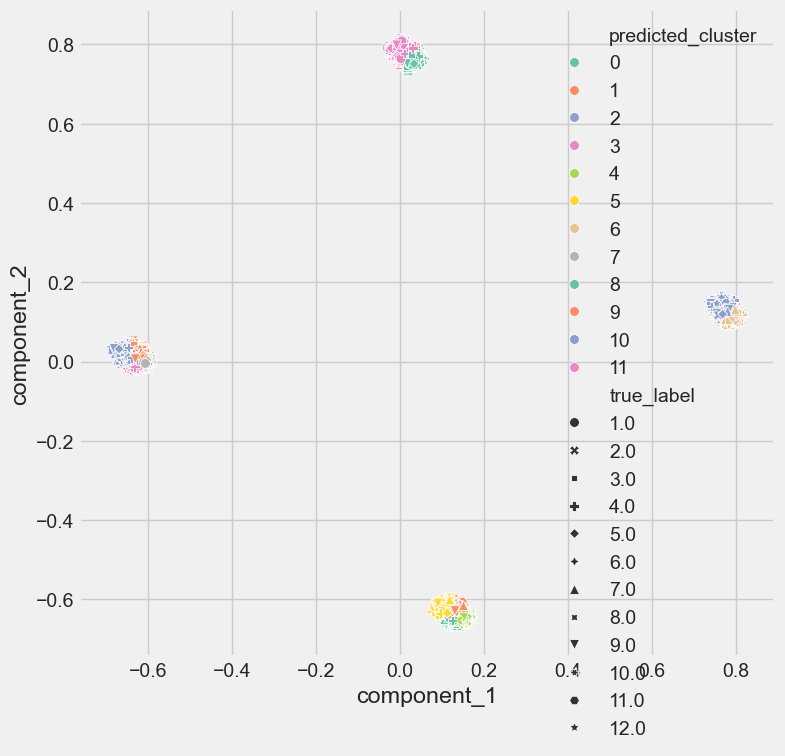

In [88]:
# Plot
plt.style.use("fivethirtyeight")
plt.figure(figsize=(8, 8))

scat = sns.scatterplot(
    data=pcadf,
    x = "component_1",
    y = "component_2",
    s=50,
    hue="predicted_cluster",
    style="true_label",
    palette="Set2",
)

Les axes ne permettent pas du tout de séparer les données et définir des clusters concernant l'ethnie des victimes.

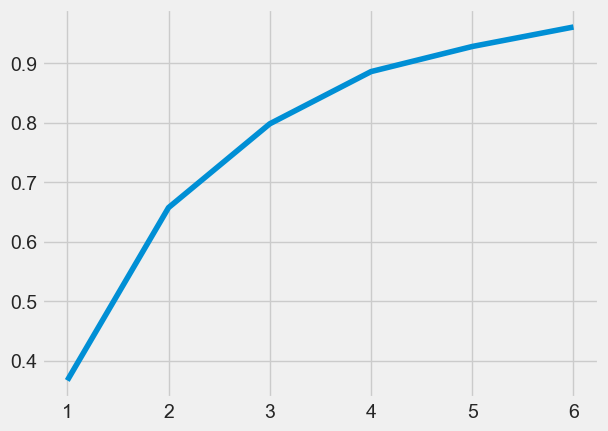

In [89]:
# Récupére et visualise la variance expliquée cumulée par les 20 premières composantes
m = 6
pipe["preprocessor"]["pca"].n_components = m
pipe.fit(data)
pipe["preprocessor"]["pca"].explained_variance_
plt.plot(
    range(1, m+1),
    np.cumsum(pipe["preprocessor"]["pca"].explained_variance_ratio_))

## Conclusion 
Ce travail a eu de pour objectif de comprendre si l'ethnie des victimes peut être prédictible en fonction des autres variables. Après avoir utilisé deux modèles statistiques, la Régression linéaire et le Principal Component Analysis, j'en conclus que les variables présentes dans le jeu de données ainsi que les variables créées et modifiées (revenu moyen par foyer, et les variables mappées) ne permettent aucunement de prédire la variable de réponse.

Les étapes appliquées ont été les suivantes:
transformations des variables texte sous forme de catégorie numérique (type d'arme, type de crime, ...)
Analyse de collinéarité.
Analyse de linéarité 

Nous avons constaté que la répartition entre les catégories n'est pas linéaire ce qui porte préjudice aux deux modèles. En effet, les données semblent être réparties uniformément dans les catégories.
Les résultats sont nuls avec un R2 proche de 0. Ce travail n'apporte rien hormis qu'il met en avant la compléxité du jeu de données et la réalité des faits. Il n'est probablement pas possible de faire de telles prédictions.

### Améliorations possibles
Je pense que les résultats auraient tout de même été meilleurs si j'avais utilisé un réseau de neurones. Les réseaux de neurones n'ont pas de contraintes, par exemple comme la nécessité d'avoir chaque variable au format numérique.

